In [1]:
setwd("~/HRJ_monocytes/hILCs")
library(data.table)
library(dplyr)
library(stringr)
library(ggplot2)
library(tidyr)
library(pheatmap)

#### Update 21st Dec 2025: Now using the new COGS results with updated ABC scores. The algo was updated, we use new activity files for 
# CD4, and we make the ABC score threshold of 0,23 for both CD4 and ILC3.

# 1. Compare COGs runs: Classic, classic+imputed, SuSIE+imputed, CD4 vs ILC3
# Make a heatmap to show which genes were prioritised by which approaches

# 2. remake the heatmaps showing contributions of COGS scores to put in the supplementary fig

# 3. Show the difference that ABC gives. For this, just show the range of COGS scores for without and with ABC (violin plot) - or show paired changes?
# with the ABC-specific genes (e.g. PTPRK) marked. And cutoff at 0.5 shown.

# 4. Make peakmatrices into UCSC tracks. Also PPIs where useful.

# 5. Get gene lists of ILC3s for FUMA.

# 6. Make nice supplementary tables.



Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘pheatmap’ was built under R version 4.1.3”


In [2]:
### Functions for comparing different prioritised genes in COGS runs.

### Load the COGS results from each run. Indicate per gene if COGS >= 0.5 and combine them.

filter_COGS <- function(dt, COGSrun) {
    dt[, c("chr37", "chr38", "biotype", "minTss37", "maxTss37", "minTss38", "maxTss38") := NULL]
    dt[cogs >= 0.5, cogs_prioritised := 1]
    dt[cogs < 0.5, cogs_prioritised := 0]
    myname <- paste0(COGSrun, "_cogs")
    setnames(dt, "cogs_prioritised", myname)
    dt[, cogs := NULL]
}

###
# draw the heatmap with row and column annotations

save_pheatmap_pdf <- function(x, filename, width=2.5, height=14) {
    stopifnot(!missing(x))
    stopifnot(!missing(filename))
    pdf(filename, width=width, height=height)
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}

paletteLength <- 10
myColor <- colorRampPalette(c("white", "coral2"))(paletteLength)

save_pheatmap_svg <- function(x, filename, width=2.5, height=14) {
    stopifnot(!missing(x))
    stopifnot(!missing(filename))
    svg(filename, width=width, height=height)
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}



## ILC3s.

              gene oldclassic_cogs oldclassic+impute_cogs oldSuSIE+impute_cogs
  1:      ATP6V1G3               0                      0                    1
  2:          BATF               0                      0                    1
  3:          BDH2               0                      0                    1
  4:          CFL1               0                      0                    1
  5:         CIITA               0                      0                    0
 ---                                                                          
108:         USP49               1                      1                    1
109:        ZBTB38               1                      1                    1
110:          JAK2               1                      0                    0
111:          CREM               1                      1                    0
112: RP11-894J14.5               1                      1                    0
     classic_cogs classic+impute_cogs SuSIE+impute_c

png 
  2

              gene Classic COGS Classic COGS + imputation multiCOGS
  1:      ATP6V1G3            0                         0         1
  2:          BATF            0                         0         1
  3:          BDH2            0                         0         1
  4:          CFL1            0                         0         1
  5:         CIITA            0                         0         1
 ---                                                               
108:         USP49            1                         1         1
109:        ZBTB38            1                         1         1
110:          JAK2            1                         0         0
111:          CREM            1                         1         0
112: RP11-894J14.5            1                         1         0


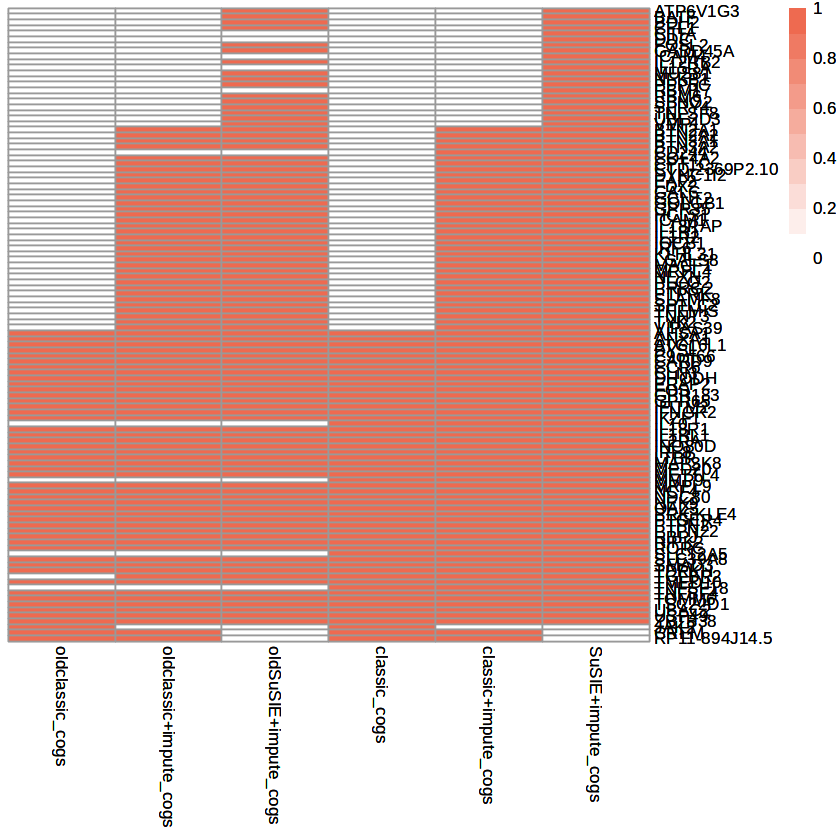

png 
  2

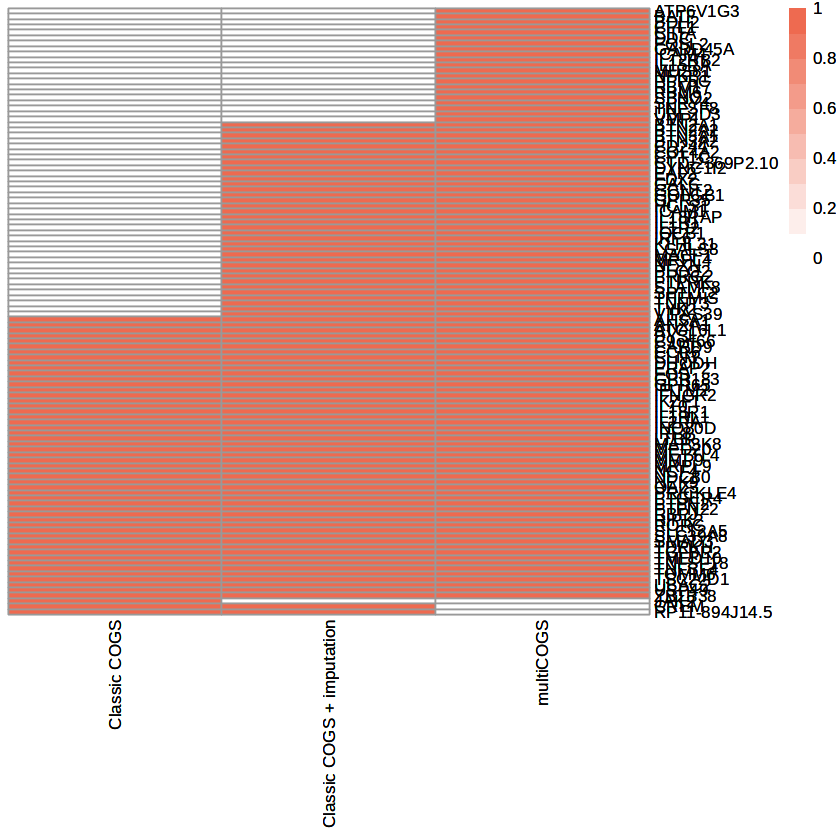

In [15]:
oldclassic <- fread("./COGS_results/COGS_out/natGen_submission1_ILCs/CD_deLange_ILCs_hg38_ClassicCOGS_combinedInteractions_ALL/Annotated_COGS_scores_data.table.txt")
filter_COGS(oldclassic, "oldclassic")
oldimpute <- fread("./COGS_results/COGS_out/natGen_submission1_ILCs/CD_deLange_ILCs_hg38_ClassicCOGS_imputed_combinedInteractions_ALL/Annotated_COGS_scores_data.table.txt")
filter_COGS(oldimpute, "oldclassic+impute")
oldsusie <- fread("./COGS_results/COGS_out/natGen_submission1_ILCs/CD_deLange_ILCs_hg38_SuSIE_combinedInteractions_ALL/Annotated_COGS_scores_data.table.txt")
filter_COGS(oldsusie, "oldSuSIE+impute")
classic <- fread("./COGS_results/COGS_out/Version3_revision2/revision_CD_deLange_ILCs_hg38_ClassicCOGS_combinedInteractions_ALL_extended_ABC023/Annotated_COGS_scores_data.table.txt")
filter_COGS(classic, "classic")
impute <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_classicCOGS_imputed_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")
filter_COGS(impute, "classic+impute")
susie <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")
filter_COGS(susie, "SuSIE+impute")

bind1 <- merge.data.table(oldclassic, oldimpute, all = T)
bind2 <- merge.data.table(bind1, oldsusie, all = T)
bind3 <- merge.data.table(bind2, classic, all = T)
bind4 <- merge.data.table(bind3, impute, all = T)
all_res <- merge.data.table(bind4, susie, all = T)

# remove cases that are NA in all three cases.
sig_res <- all_res[oldclassic_cogs == 1 | `oldclassic+impute_cogs` == 1 | `oldSuSIE+impute_cogs` == 1 | classic_cogs == 1 | `classic+impute_cogs` == 1 | `SuSIE+impute_cogs` == 1 ]

# set remaining NA to 0
sig_res[is.na(sig_res)] <- 0

# if there's no gene name, put the ENSG ID. then, remove the ensg column.
# might need to look these up. Not sure if I did before.
sig_res[gene == "", gene := ensg]
sig_res[, ensg := NULL]

# set col order manually
setorder(sig_res, cols = -"SuSIE+impute_cogs", "classic+impute_cogs", "classic_cogs", "gene")


print(sig_res)

# Make the heatmap to show genes prioritised in the different runs of COGS (classic, imputed or SuSIE imputed)
mat <- as.data.frame(sig_res)
rownames(mat) <- mat[,1]
mat2 <- mat[ -c(1) ]



p <- pheatmap(mat2, cluster_rows = F, cluster_cols = F, 
              color = myColor) 
save_pheatmap_pdf(p, "./COGS_results/comparisons/oldABC-vnewABC_cutoff_heatmap_classicVimputeVsusie_Jan25.pdf")
p

####### Now make the version for the paper supplementary, which just shows the new results - with less stringent ABC cutoff
bind1 <- merge.data.table(classic, impute, all = T)
all_res <- merge.data.table(bind1, susie, all = T)

# remove cases that are NA in all three cases.
sig_res <- all_res[classic_cogs == 1 | `classic+impute_cogs` == 1 | `SuSIE+impute_cogs` == 1 ]

# set remaining NA to 0
sig_res[is.na(sig_res)] <- 0

# if there's no gene name, put the ENSG ID. then, remove the ensg column.
# might need to look these up. Not sure if I did before.
sig_res[gene == "", gene := ensg]
sig_res[, ensg := NULL]

# set col order manually
setorder(sig_res, cols = -"SuSIE+impute_cogs", "classic+impute_cogs", "classic_cogs", "gene")
names(sig_res) = c("gene", "Classic COGS", "Classic COGS + imputation", "multiCOGS")

print(sig_res)

# Make the heatmap to show genes prioritised in the different runs of COGS (classic, imputed or SuSIE imputed)
mat <- as.data.frame(sig_res)
rownames(mat) <- mat[,1]
mat2 <- mat[ -c(1) ]



p <- pheatmap(mat2, cluster_rows = F, cluster_cols = F, 
              color = myColor, angle_col = "90") 
save_pheatmap_svg(p, "./COGS_results/comparisons/ILC3_heatmap_classicVimputeVsusie_Jan25.svg")
p

### Save the dataframe too.
fwrite(sig_res, file = "./COGS_results/comparisons/ILC3_heatmap_classicVimputeVsusie_Jan25.txt", sep= "\t", 
      quote = F, row.names = F, col.names = T)

#sum(sig_res$classic_cogs)
#sum(sig_res$`classic+impute_cogs`)
#sum(sig_res$`SuSIE+impute_cogs`)
#(90-55)/90

#susie_sig <- susie[`SuSIE+impute_cogs` == 1]
#sig_annot <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/sigAnnotated_ILC3_multiCOGS_scores_data.table.txt")
#susie_sig[!ensg %in% sig_annot$ensg] # PRICKLE4 - careful, it was not put into sig table with awk in BASH because of not having a Ts37 


# save the correct no. of sig genes in the set! R better than bash.
susie2 <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")
susie2_sig <- susie2[cogs >= 0.5]
fwrite(susie2_sig, file = "./COGS_results/COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/sig_Annotated_COGS_scores_data.table.txt", 
      sep = "\t", quote = F, row.names = F, col.names = T)

## CD4s.

              gene classic_cogs classic+impute_cogs SuSIE+impute_cogs
  1:      ATP6V1G3            0                   0                 1
  2:          BATF            0                   0                 1
  3:          BDH2            0                   0                 1
  4:         CIITA            0                   0                 1
  5:         CISD2            0                   0                 1
 ---                                                                 
118:        ZBTB38            1                   1                 1
119:          FRS2            1                   0                 0
120:        IL18R1            1                   0                 0
121:          JAK2            1                   0                 0
122: RP11-894J14.5            1                   1                 0


png 
  2

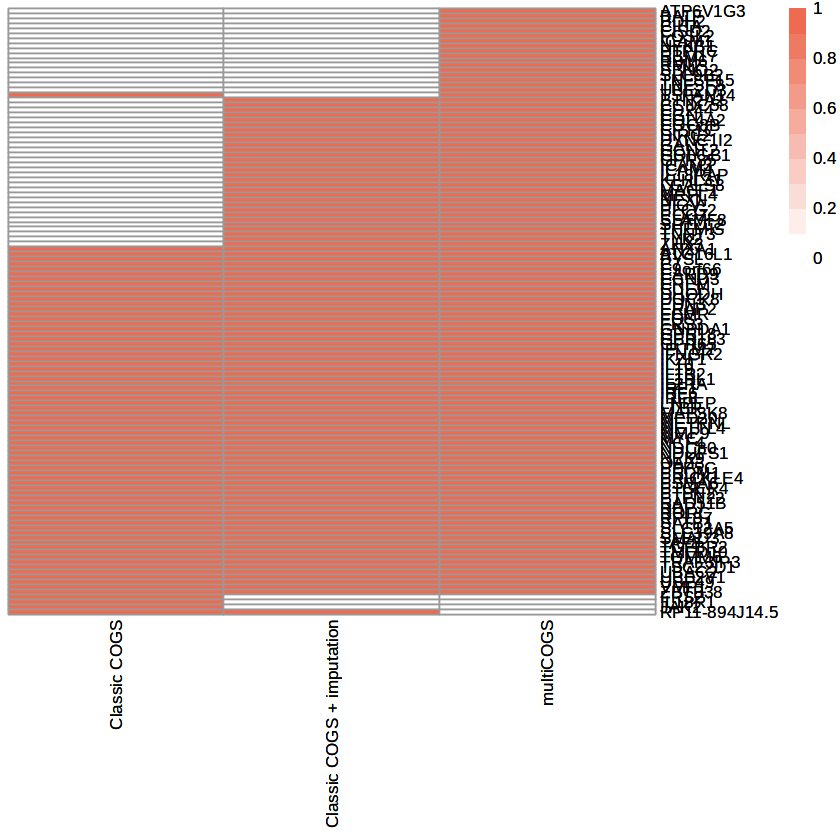

In [16]:


classic <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_CD4s_hg38_classicCOGS_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")
filter_COGS(classic, "classic")
impute <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_CD4s_hg38_classicCOGS_imputed_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")
filter_COGS(impute, "classic+impute")
susie <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_CD4s_hg38_SuSIE_fix_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")
filter_COGS(susie, "SuSIE+impute")

bind1 <- merge.data.table(classic, impute, all = T)
all_res <- merge.data.table(bind1, susie, all = T)

# remove cases that are NA in all three cases.
sig_res <- all_res[classic_cogs == 1 | `classic+impute_cogs` == 1 | `SuSIE+impute_cogs` == 1 ]

# set remaining NA to 0
sig_res[is.na(sig_res)] <- 0

# if there's no gene name, put the ENSG ID. then, remove the ensg column.
# might need to look these up. Not sure if I did before.
sig_res[gene == "", gene := ensg]
sig_res[, ensg := NULL]

# set col order manually
setorder(sig_res, cols = -"SuSIE+impute_cogs", "classic+impute_cogs", "classic_cogs", "gene")


print(sig_res)
names(sig_res) = c("gene", "Classic COGS", "Classic COGS + imputation", "multiCOGS")

# Make the heatmap to show genes prioritised in the different runs of COGS (classic, imputed or SuSIE imputed)
mat <- as.data.frame(sig_res)
rownames(mat) <- mat[,1]
mat2 <- mat[ -c(1) ]


p <- pheatmap(mat2, cluster_rows = F, cluster_cols = F, 
              color = myColor, angle_col = 90) 
save_pheatmap_svg(p, "./COGS_results/comparisons/CD4_heatmap_classicVimputeVsusie_Jan25.svg")
p

### Save the dataframe too.
fwrite(sig_res, file = "./COGS_results/comparisons/CD4_heatmap_classicVimputeVsusie_Jan25.txt", sep= "\t", 
      quote = F, row.names = F, col.names = T)

#sum(sig_res$classic_cogs)
#sum(sig_res$`classic+impute_cogs`)
#sum(sig_res$`SuSIE+impute_cogs`)
#(101-75)/101

# save the correct no. of sig genes in the set! R better than bash.
susie2 <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_CD4s_hg38_SuSIE_fix_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")
susie2_sig <- susie2[cogs >= 0.5]
fwrite(susie2_sig, file = "./COGS_results/COGS_out/Version3_revision2/revision_deLange_CD4s_hg38_SuSIE_fix_combinedInteractions_extended_ABC023/sig_Annotated_COGS_scores_data.table.txt", 
      sep = "\t", quote = F, row.names = F, col.names = T)

## ILCs versus CD4s

         gene ILC3_cogs CD4_cogs
  1:    AHSA1         1        0
  2:   BTN2A1         1        0
  3:   BTN3A1         1        0
  4:   BTN3A2         1        0
  5:     CCR6         1        0
 ---                            
143:  TNFSF15         0        1
144: TRAF3IP3         0        1
145:  TSPAN14         0        1
146:   UBE2V1         0        1
147:     ZHX3         0        1


png 
  2

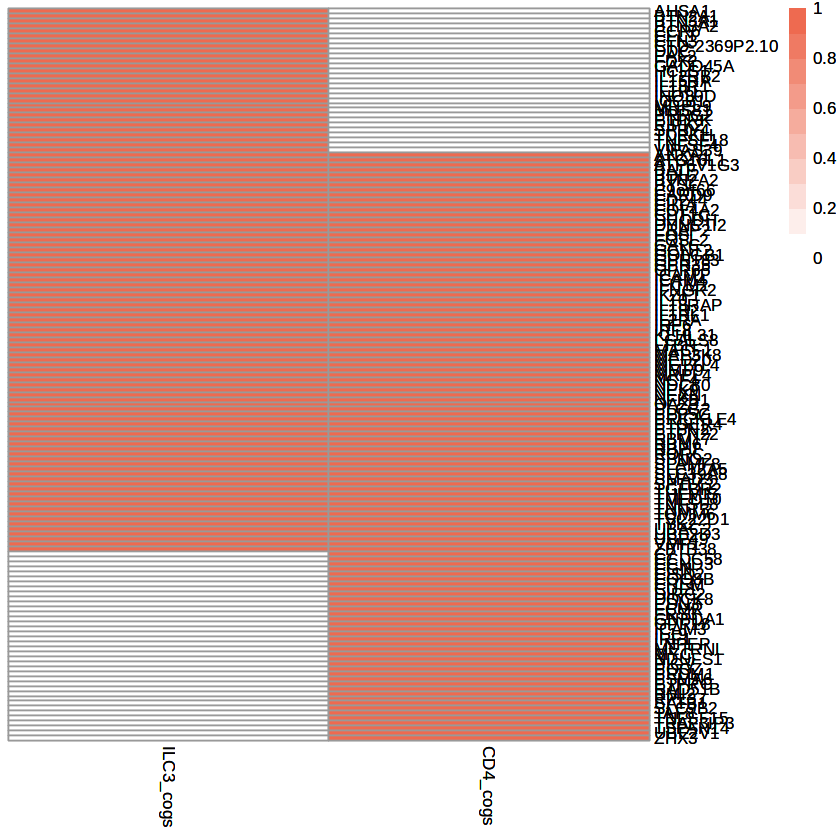

In [6]:
ILC <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")
filter_COGS(ILC, "ILC3")
CD4 <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_CD4s_hg38_SuSIE_fix_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")
filter_COGS(CD4, "CD4")

all_res <- merge.data.table(ILC, CD4, all = T)

# remove cases that are NA in all three cases.
sig_res <- all_res[CD4_cogs == 1 | ILC3_cogs == 1 ]

# set remaining NA to 0
sig_res[is.na(sig_res)] <- 0

# if there's no gene name, put the ENSG ID. then, remove the ensg column.
# might need to look these up. Not sure if I did before.
sig_res[gene == "", gene := ensg]
sig_res[, ensg := NULL]

# set col order manually
setorder(sig_res, cols = -"ILC3_cogs", "CD4_cogs", "gene")


print(sig_res)

# Make the heatmap to show genes prioritised in the different runs of COGS (classic, imputed or SuSIE imputed)
mat <- as.data.frame(sig_res)
rownames(mat) <- mat[,1]
mat2 <- mat[ -c(1) ]



p <- pheatmap(mat2, cluster_rows = F, cluster_cols = F, 
              color = myColor) 
save_pheatmap_pdf(p, "./COGS_results/comparisons/ILC3_vs_CD4_SuSIE_2025.pdf", height = 20, width = 6)
p

### Save the dataframe too.
fwrite(sig_res, file = "./COGS_results/comparisons/ILC3_vs_CD4_SuSIE_2025.txt", sep= "\t", 
      quote = F, row.names = F, col.names = T)



### Heatmap of contributions from different regions, for ILC3s and CD4s. 

In [4]:
### 1. ILC3s.
### Make heatmap showing contributions from all COGS components
# the ones to use are from: susie. but need to keep the ensgid and the overall score
#susie <- fread("./COGS_results/COGS_out/revision_CD_deLange_ILCs_hg38_SuSIE_combinedInteractions_ALL/Annotated_COGS_scores_data.table.txt")
susie <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")
susie[, c("chr37", "chr38", "biotype", "minTss37", "maxTss37", "minTss38", "maxTss38") := NULL]
susie_sig <- susie[cogs >= 0.5]
#print(susie_sig)

# to load:
### 5kb interactions
### fragres interactions
### ABC 
### VProm
### Coding

filter_cogs_keepScores <- function(dt, COGSrun) {
    dt[, c("chr37", "chr38", "biotype", "minTss37", "maxTss37", "minTss38", "maxTss38") := NULL]
    myname <- paste0(COGSrun, "_cogs")
    setnames(dt, "cogs", myname)
}

CHiC <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023_CHiCOnly/Annotated_COGS_scores_data.table.txt")
nrow(CHiC[cogs >= 0.5])
filter_cogs_keepScores(CHiC, "CHiC")


abc <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023_ABConly/Annotated_COGS_scores_data.table.txt")
nrow(abc[cogs >= 0.5])
filter_cogs_keepScores(abc, "abc")

vprom <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023_VPromOnly/Annotated_COGS_scores_data.table.txt")
filter_cogs_keepScores(vprom, "vprom")

coding <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023_CodingOnly/Annotated_COGS_scores_data.table.txt")
nrow(coding[cogs >= 0.5])
#print(coding[cogs >= 0.5])
filter_cogs_keepScores(coding, "coding")

bind1 <- CHiC[susie_sig, on = c("ensg", "gene")] # keep only those that are significant in overall COGS (in susie_sig)
# now merge the rest in the same way
bind2 <- vprom[bind1, on = c("ensg", "gene")]
bind3 <- coding[bind2, on = c("ensg", "gene")]
allCogs <- abc[bind3, on = c("ensg", "gene")]

allCogs[, ensg := NULL]

names(allCogs) = c("gene", "ABCC score", "Coding score", "Promoter score", "CHiC score", "multiCOGS score")

print(allCogs[1:3, ])


[1] 60

[1] 14

[1] 4

       gene   ABCC score Coding score Promoter score CHiC score multiCOGS score
1:  GADD45A 6.144312e-05 0.000000e+00   4.745396e-05  0.9996657       0.9996665
2:     NCF4 1.830084e-04 5.589490e-06   9.977553e-01         NA       0.9979039
3: ATP6V1G3           NA 5.379903e-08   9.948705e-07  0.9976102       0.9976113


png 
  2

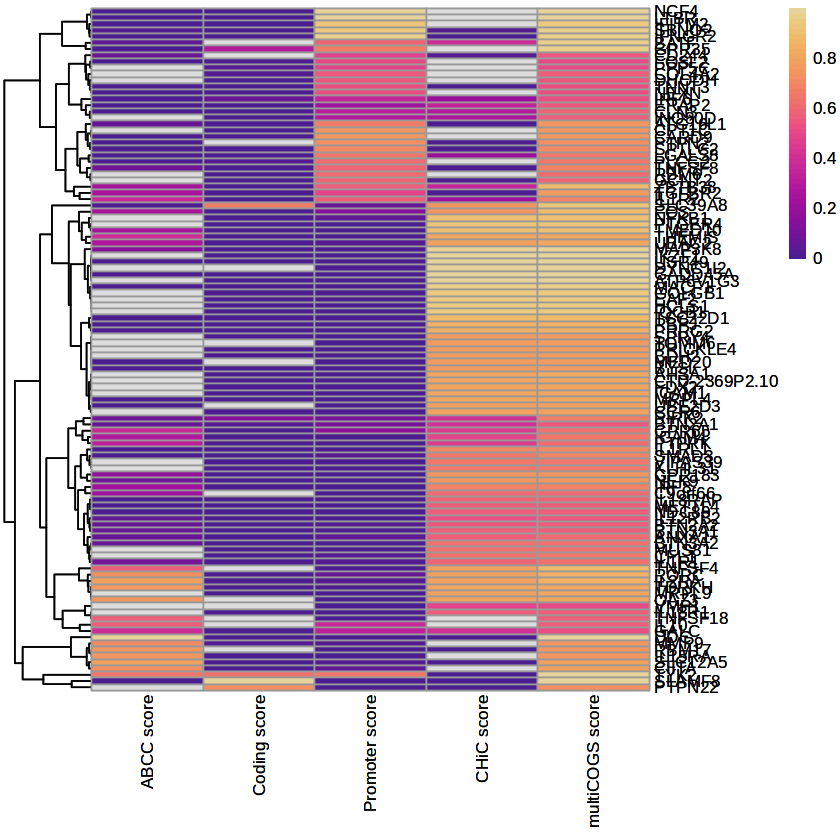

In [21]:
### Make the heatmap

mat <- as.data.frame(allCogs)
rownames(mat) <- mat[,1]
mat2 <- mat[ -c(1) ]

# draw the heatmap with row and column annotations
paletteLength <- 50
myColor1 <- colorRampPalette(grDevices::hcl.colors(50, palette = "ag_sunset"))
myColor <- myColor1(50)

save_pheatmap_svg <- function(x, filename, width=3.5, height=14) {
    stopifnot(!missing(x))
    stopifnot(!missing(filename))
    svg(filename, width=width, height=height)
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}

p <- pheatmap(mat2, cluster_rows = T, cluster_cols = F, 
              color = myColor, angle_col = 90) 
save_pheatmap_svg(p, "./COGS_results/comparisons/revision_ILC3_heatmap_COGScontributions_June25.svg")
p

In [5]:
### 2. CD4s.
### Make heatmap showing contributions from all COGS components
# the ones to use are from: susie. but need to keep the ensgid and the overall score
#susie <- fread("./COGS_results/COGS_out/revision_CD_deLange_ILCs_hg38_SuSIE_combinedInteractions_ALL/Annotated_COGS_scores_data.table.txt")
susie <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_CD4s_hg38_SuSIE_fix_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")
susie[, c("chr37", "chr38", "biotype", "minTss37", "maxTss37", "minTss38", "maxTss38") := NULL]
susie_sig <- susie[cogs >= 0.5]
#print(susie_sig)

# to load:
### 5kb interactions
### fragres interactions
### ABC 
### VProm
### Coding

filter_cogs_keepScores <- function(dt, COGSrun) {
    dt[, c("chr37", "chr38", "biotype", "minTss37", "maxTss37", "minTss38", "maxTss38") := NULL]
    myname <- paste0(COGSrun, "_cogs")
    setnames(dt, "cogs", myname)
}

CHiC <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_CD4s_hg38_SuSIE_fix_combinedInteractions_extended_ABC023_CHiCOnly/Annotated_COGS_scores_data.table.txt")
nrow(CHiC[cogs >= 0.5])
filter_cogs_keepScores(CHiC, "CHiC")


abc <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_CD4s_hg38_SuSIE_fix_combinedInteractions_extended_ABC023_ABConly/Annotated_COGS_scores_data.table.txt")
nrow(abc[cogs >= 0.5])
filter_cogs_keepScores(abc, "abc")

vprom <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_CD4s_hg38_SuSIE_fix_combinedInteractions_extended_ABC023_VPromOnly/Annotated_COGS_scores_data.table.txt")
filter_cogs_keepScores(vprom, "vprom")

coding <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_CD4s_hg38_SuSIE_fix_combinedInteractions_extended_ABC023_CodingOnly/Annotated_COGS_scores_data.table.txt")
nrow(coding[cogs >= 0.5])
#print(coding[cogs >= 0.5])
filter_cogs_keepScores(coding, "coding")

bind1 <- CHiC[susie_sig, on = c("ensg", "gene")] # keep only those that are significant in overall COGS (in susie_sig)
# now merge the rest in the same way
bind2 <- vprom[bind1, on = c("ensg", "gene")]
bind3 <- coding[bind2, on = c("ensg", "gene")]
allCogs <- abc[bind3, on = c("ensg", "gene")]

allCogs[, ensg := NULL]

names(allCogs) = c("gene", "ABCC score", "Coding score", "Promoter score", "CHiC score", "multiCOGS score")

print(allCogs[1:3, ])

[1] 70

[1] 14

[1] 4

    gene   ABCC score Coding score Promoter score CHiC score multiCOGS score
1: SMAD3 1.110223e-15 0.000000e+00   2.391071e-02  0.9760893       1.0000000
2:  FCMR 6.710821e-11 3.881007e-12   2.315592e-11  0.9999995       0.9999995
3: IKZF1           NA 4.039407e-06   7.977287e-05  0.9999993       0.9999993


png 
  2

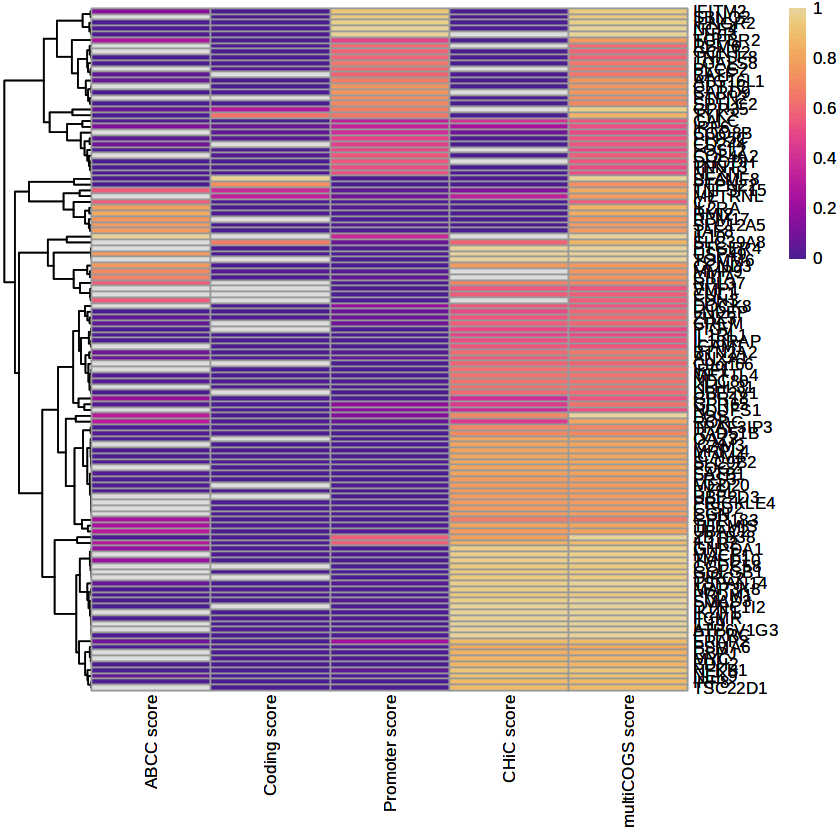

In [7]:
### Make the heatmap

mat <- as.data.frame(allCogs)
rownames(mat) <- mat[,1]
mat2 <- mat[ -c(1) ]

# draw the heatmap with row and column annotations
paletteLength <- 50
myColor1 <- colorRampPalette(grDevices::hcl.colors(50, palette = "ag_sunset"))
myColor <- myColor1(50)

save_pheatmap_svg <- function(x, filename, width=3, height=14) {
    stopifnot(!missing(x))
    stopifnot(!missing(filename))
    svg(filename, width=width, height=height)
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}

p <- pheatmap(mat2, cluster_rows = T, cluster_cols = F, 
              color = myColor, angle_col = 90) 
save_pheatmap_svg(p, "./COGS_results/comparisons/revision_CD4_heatmap_COGScontributions_June25.svg")
p

### Show changes from ABC.
##### now doing in both ILC3 and CD4

Warning message:
“Removed 55 rows containing non-finite outside the scale range
(`stat_ydensity()`).”


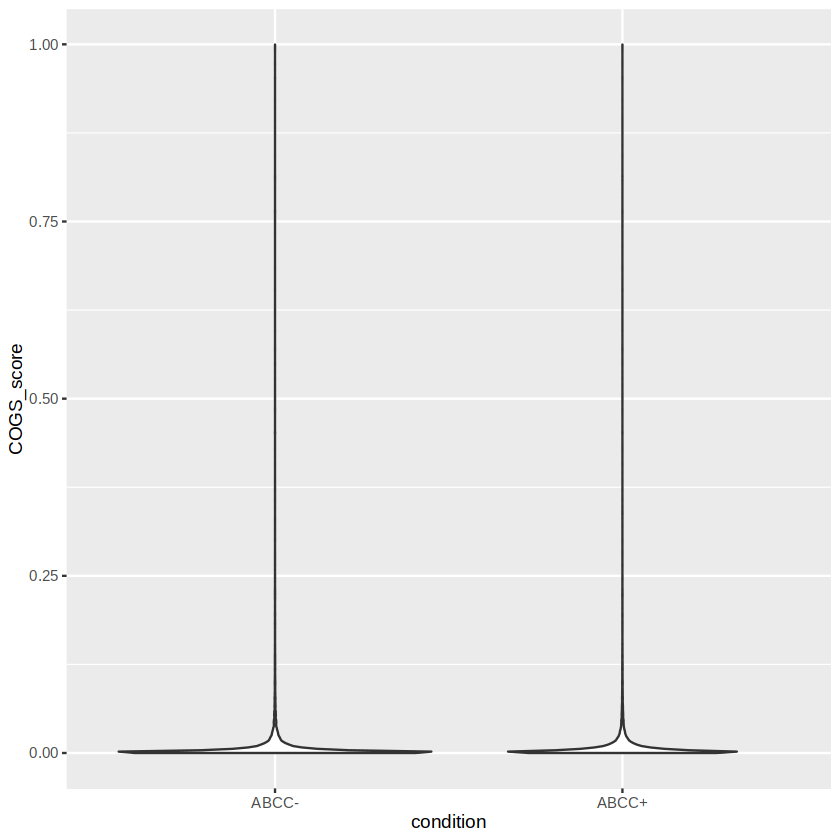

In [41]:
#library(ggpubr)
#ggpaired()
### first see how a simple boxplot looks.
susie_noabc <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023_NoABC/Annotated_COGS_scores_data.table.txt")
susie_noabc[, c("chr37", "chr38", "biotype", "minTss37", "maxTss37", "minTss38", "maxTss38") := NULL]
setnames(susie_noabc, "cogs", "ABCC-")
susie <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")
susie[, c("chr37", "chr38", "biotype", "minTss37", "maxTss37", "minTss38", "maxTss38") := NULL]
setnames(susie, "cogs", "ABCC+")

both <- merge.data.table(susie_noabc, susie, on  = c("ensg", "gene"), all = T)

# melt for ggplot
both_toplot <- melt.data.table(both, id.vars = c("ensg", "gene"), measure.vars = c("ABCC-", "ABCC+"), variable.name = "condition", value.name = "COGS_score")
both_toplot[, id := paste(ensg, gene, sep = "_")]
both_toplot[, c("ensg", "gene") := NULL]
#print(both_toplot)

library(ggplot2)
p <- ggplot(both_toplot, aes(x = condition, y = COGS_score)) + geom_violin()
print(p)
# not good, so many at zero

png 
  2

condition,COGS_score,id,Gene
<fct>,<dbl>,<chr>,<chr>


condition,COGS_score,id,Gene
<fct>,<dbl>,<chr>,<chr>


condition,COGS_score,id,Gene
<fct>,<dbl>,<chr>,<chr>


[1] 109

[1] 11

[1] 10.09174

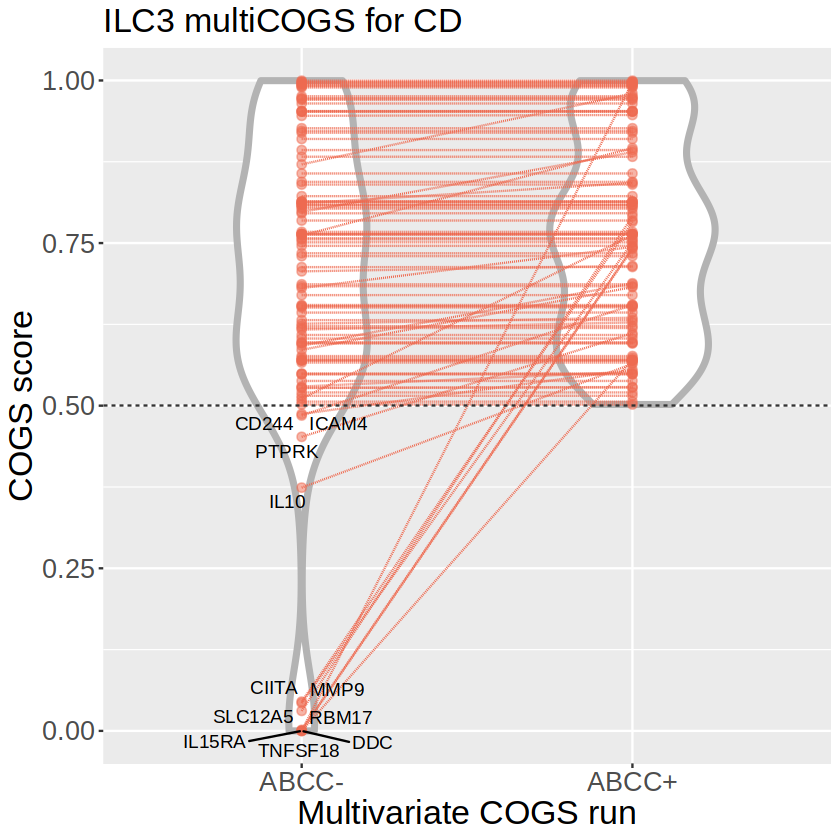

png 
  2

[1] 118

[1] 14

[1] 11.86441

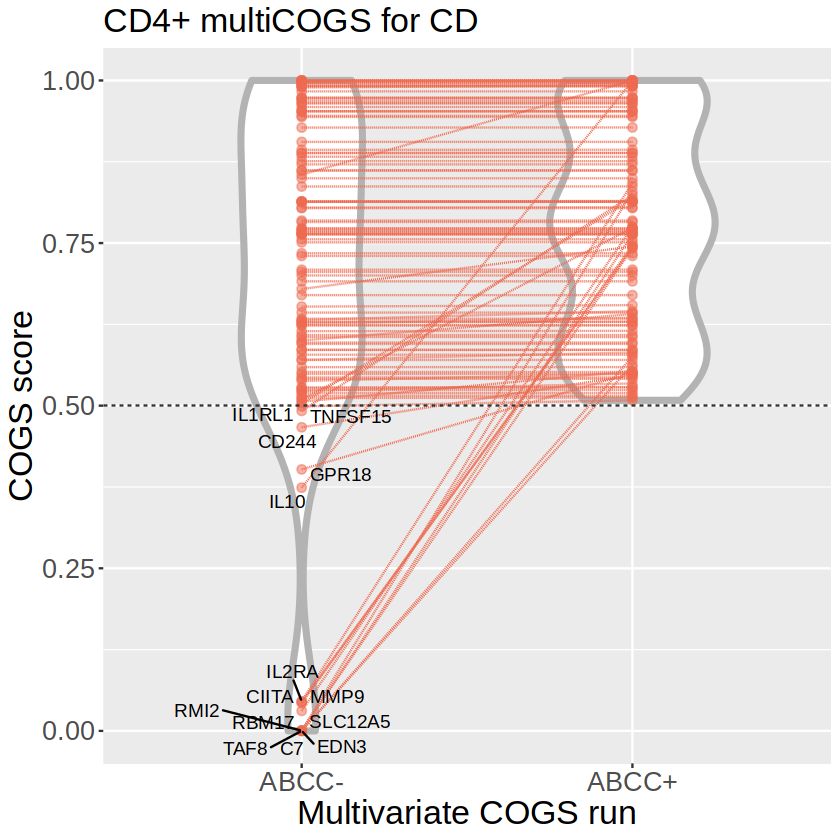

In [44]:
# only show increases for genes significant in ABC

both_sigABC <- both[`ABCC+` >= 0.5]
# melt for ggplot
both_toplot2 <- melt.data.table(both_sigABC, id.vars = c("ensg", "gene"), measure.vars = c("ABCC-", "ABCC+"), variable.name = "condition", value.name = "COGS_score")
both_toplot2[, id := paste(ensg, gene, sep = "_")]
both_toplot2[, c("ensg", "gene") := NULL]

library(ggrepel)
both_toplot2[, c("id", "Gene") := tstrsplit(id, split = "_")]
q <- ggplot(both_toplot2, aes(x = condition, y = COGS_score)) + 
  geom_violin(width=0.5, size=1.5, colour="grey70") + 
  geom_point(colour="coral2", size=2, alpha=0.5) +
  geom_line(aes(group=id), colour="coral2", linetype="11") +
  theme(text = element_text(size = 20)) +
  ylab("COGS score") +
  xlab("Multivariate COGS run") + 
  ylim(0, 1) + 
labs(subtitle = "ILC3 multiCOGS for CD") +
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "gray20") + 
  geom_text_repel(aes(label=ifelse(COGS_score<0.5,as.character(Gene),'')), max.overlaps = 1000)
print(q)

svg(file = "./COGS_results/comparisons/revision_violinplots_ABCvsnoABC_withLines_Sept25.svg", width = 7, height = 7)
print(q)
dev.off()
both_toplot2[id %like% "PTPRK"]
both_toplot2[id %like% "IL10"]
both_toplot2[id %like% "ZPBP"]


all <- both[`ABCC+` > 0.5]
only_withABC <- both[`ABCC+` > 0.5 & `ABCC-` <= 0.5]
length(unique(all$ensg))
length(unique(only_withABC$ensg))
proportion = length(unique(only_withABC$ensg))/length(unique(all$ensg)) * 100
proportion # For ILC3s, it is 11/109 = 10.09%


### Do the same as above, for CD4+ T cells.

susie_CD4 <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_CD4s_hg38_SuSIE_fix_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")
susie_CD4[, c("chr37", "chr38", "biotype", "minTss37", "maxTss37", "minTss38", "maxTss38") := NULL]
setnames(susie_CD4, "cogs", "ABCC+")
susie_noabc_CD4 <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_CD4s_hg38_SuSIE_fix_combinedInteractions_extended_ABC023_NoABC/Annotated_COGS_scores_data.table.txt")
susie_noabc_CD4[, c("chr37", "chr38", "biotype", "minTss37", "maxTss37", "minTss38", "maxTss38") := NULL]
setnames(susie_noabc_CD4, "cogs", "ABCC-")

both_CD4 <- merge.data.table(susie_noabc_CD4, susie_CD4, on  = c("ensg", "gene"), all = T)

# only show increases for genes significant in ABC

both_CD4_sigABC <- both_CD4[`ABCC+` >= 0.5]
# melt for ggplot
both_CD4_toplot2 <- melt.data.table(both_CD4_sigABC, id.vars = c("ensg", "gene"), measure.vars = c("ABCC-", "ABCC+"), variable.name = "condition", value.name = "COGS_score")
both_CD4_toplot2[, id := paste(ensg, gene, sep = "_")]
both_CD4_toplot2[, c("ensg", "gene") := NULL]

both_CD4_toplot2[, c("id", "Gene") := tstrsplit(id, split = "_")]
q1 <- ggplot(both_CD4_toplot2, aes(x = condition, y = COGS_score)) + 
  geom_violin(width=0.5, size=1.5, colour="grey70") + 
  geom_point(colour="coral2", size=2, alpha=0.5) +
  geom_line(aes(group=id), colour="coral2", linetype="11") +
  theme(text = element_text(size = 20)) +
  ylab("COGS score") +
  xlab("Multivariate COGS run") + 
  ylim(0, 1) + 
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "gray20") + 
labs(subtitle = "CD4+ multiCOGS for CD") +
  geom_text_repel(aes(label=ifelse(COGS_score<0.5,as.character(Gene),'')), max.overlaps = 1000)
print(q1)

svg(file = "./COGS_results/comparisons/revision_violinplots_ABCvsnoABC_withLines_CD4_Sept25.svg", width = 7, height = 7)
print(q1)
dev.off()

all_CD4 <- both_CD4[`ABCC+` > 0.5]
only_withABC_CD4 <- both_CD4[`ABCC+` > 0.5 & `ABCC-` <= 0.5]
length(unique(all_CD4$ensg))
length(unique(only_withABC_CD4$ensg))
proportion_CD4 = length(unique(only_withABC_CD4$ensg))/length(unique(all_CD4$ensg)) * 100
proportion_CD4 # For CD4s, is is 11.86

# mean of 10.09 and 11.86 = 10.975 = 11% of multiCOGS genes were added by ABCC.

png 
  2

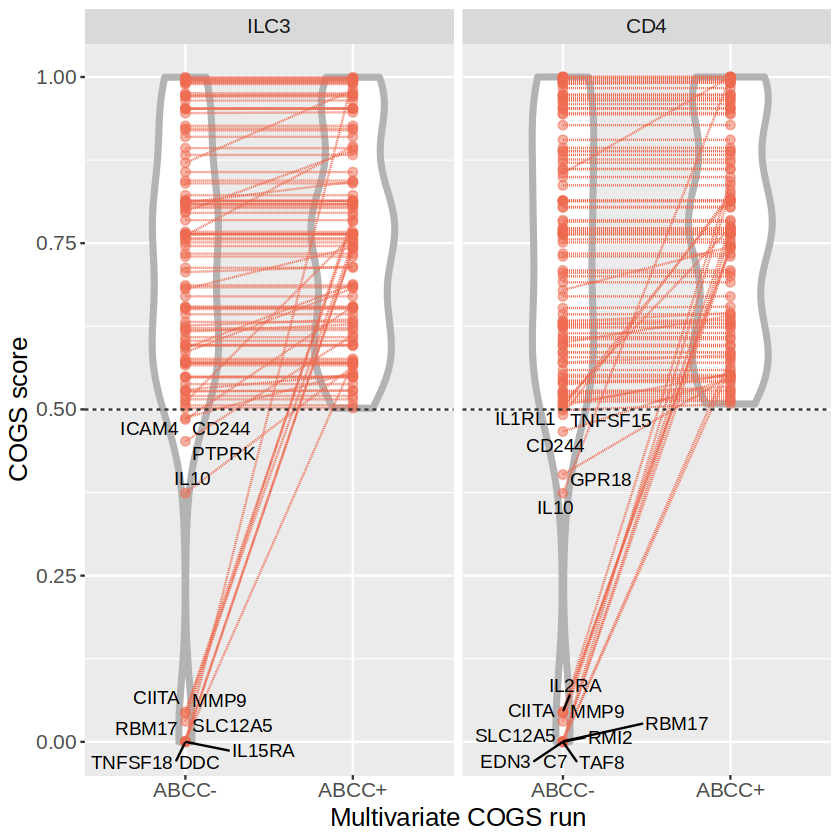

In [48]:
library(forcats)
both_toplot2[, cell := "ILC3"]
both_CD4_toplot2[, cell := "CD4"]
both_Cells <- rbind(both_toplot2, both_CD4_toplot2)

q3 <- ggplot(both_Cells, aes(x = condition, y = COGS_score)) + 
  geom_violin(width=0.5, size=1.5, colour="grey70") + 
  geom_point(colour="coral2", size=2, alpha=0.5) +
  geom_line(aes(group=id), colour="coral2", linetype="11") +
  theme(text = element_text(size = 15)) +
  ylab("COGS score") +
  xlab("Multivariate COGS run") + 
  ylim(0, 1) + 
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "gray20") + 
  geom_text_repel(aes(label=ifelse(COGS_score<0.5,as.character(Gene),'')), max.overlaps = 1000) + facet_wrap(~fct_rev(cell))
print(q3)

svg(file = "./COGS_results/comparisons/revision_violinplots_ABCvsnoABC_withLines_bothCellTypes_Sept25.svg", width = 7, height = 7)
print(q3)
dev.off()

### The chunks from hereon focus on making bed files/UCSC tracks for interactions and PPIs. 

This code has been updated for the new ABC results as of Jan 2025.
Note that PPIs should not have changed since the first submission. Interactions may have changed if they include ABC results.

In [5]:
## Todo: get bed files for genes of interest. Below was for when we only had PTPRK as an ABC-gene.
setwd("~/HRJ_monocytes/hILCs/")
library(data.table)
options(scipen = 999)

### Get bed files/interactions for ABC versus fiveKB in the PTPRK locus
#susie <- fread("./COGS_results/COGS_out/CD_deLange_ILCs_hg38_SuSIE_combinedInteractions_ALL/Annotated_COGS_scores_data.table.txt")
myChrom <- 6
myStart <- 127500000
myEnd <-  129500000

#ppis <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_CD4s_hg38_classicCOGS_combinedInteractions_extended_ABC023/COGS_PPIs_data.table.txt")
ppis_PTPRK <- ppis[pos >= 127500000 & pos <= 129500000]
range(ppis_PTPRK$ppi)

ppis_bed1 <- ppis_PTPRK[, .(chr, pos, ppi)]
ppis_bed1[, pos0 := pos-1 ]
ppis_bed1[, chrom := paste0("chr", chr)]
ppis_bed <- ppis_bed1[, .(chrom, pos0, pos, ppi)]
print(ppis_bed)
fwrite(ppis_bed, file = "./browser_tracks/PTPRK_region_ppis.bedgraph", sep = "\t", quote  = F, 
       row.names = F, col.names = F)

### Also find the credible sets. 
print(ppis_PTPRK[ppi > 0.01 & chr == 6])


### To get larger bedgraphs:
get_bedgraph <- function(bg, outname, mychr) {
  bg[, chr := paste0("chr", chr)]
  bg[, pos0 := pos-1]
  bg2 <- bg[, .(chr, pos0, pos, ppi)]
  high <- bg2[ppi > 0.01]
  twrite <- high[chr == mychr]
  fwrite(twrite, file = outname, sep = "\t", quote = F, row.names = F, col.names = F)
  return(twrite)
}

IBD <- fread("./COGS_results/COGS_out/IBD_DeLange_28067908/IBD_DeLange_28067908_CD4_SuSIE/COGS_PPIs_data.table.txt")
IBD_res <- get_bedgraph(IBD, "./browser_tracks/IBD_PPI_chr7.bedgraph", "chr7")

print(head(IBD_res))

UC <- fread("./COGS_results/COGS_out/UC_DeLange_28067908/UC_DeLange_28067908_CD4_SuSIE/COGS_PPIs_data.table.txt")
UC_res <- get_bedgraph(UC, "./browser_tracks/UC_PPI_chr7.bedgraph", "chr7")

print(head(UC_res))


[1] 0.000000000005031134 0.373427457285984976

       chrom      pos0       pos            ppi
    1: chr10 127500020 127500021 0.000009283556
    2: chr10 127501874 127501875 0.000020839468
    3: chr10 127502110 127502111 0.000017936146
    4: chr10 127502199 127502200 0.000007459245
    5: chr10 127502386 127502387 0.000011504377
   ---                                         
43033:  chr9 129497799 129497800 0.000009129646
43034:  chr9 129498070 129498071 0.000010826324
43035:  chr9 129498748 129498749 0.000009410558
43036:  chr9 129499712 129499713 0.000012945729
43037:  chr9 129499863 129499864 0.000007405354
Empty data.table (0 rows and 11 cols): chr,start,end,ld,pid,pos...
    chr     pos0      pos        ppi
1: chr7 99081398 99081399 0.01636325
2: chr7 99080862 99080863 0.01406740
3: chr7 99076738 99076739 0.01262487
4: chr7 99073285 99073286 0.01176434
5: chr7 99067940 99067941 0.02488271
6: chr7 99050061 99050062 0.02022021
    chr     pos0      pos        ppi
1: chr7 98617645 98617646 0.01259110
2: chr7 98614233 9861423

In [10]:
### Get the ABC interactions, fiveK interactions and DpnII interactions for the gene in question
### Also genome-wide..
library(data.table)
setwd("~/HRJ_monocytes/hILCs")
ints <- fread("~/HRJ_monocytes/hILCs/rCOGS_in/Version3_revision2/COGS_input_revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/ILC3_chicago_fres_bin_5kb_abc_023_fres_extended_peakm_13012025_modified.txt_pm.format.txt")
head(ints)
## check oeChr problem was fixed
#ints[is.na(oeChr)]
#ints[oeChr == ""]

# Change the coords for WashU 
ints[baitStart < oeStart, `:=` (leftChr = paste0("chr", baitChr), 
                                 leftStart = baitStart, 
                                 leftEnd = baitEnd, 
                                 rightChr = paste0("chr", oeChr),
                                 rightStart = oeStart,
                                 rightEnd = oeEnd)]
ints[baitStart > oeStart, `:=` (leftChr = paste0("chr", oeChr), 
                                 leftStart = oeStart, 
                                 leftEnd = oeEnd, 
                                 rightChr = paste0("chr", baitChr),
                                 rightStart = baitStart,
                                 rightEnd = baitEnd)]

ints[, washURight_temp := paste(rightChr, rightStart, sep = ":")]
ints[, washURight_temp2 := paste(washURight_temp, rightEnd, sep = "-")]

## PTPRK - no longer doing.

### Genome-wide: Print all interactions, ABC fres and fiveKB
abc <- ints[!is.na(`ABC.Score`)]
abc[, washURight := paste(washURight_temp2, `ABC.Score`, sep = ",")]
abc_washU <- abc[, .(leftChr, leftStart, leftEnd, washURight)]
print(abc_washU)
fwrite(abc_washU, file = "./browser_tracks/GenomeWide_ABC_ints_WashU.txt", sep = "\t", quote = F, row.names = F, col.names = F)


## The resolution here: I think the baits and OE are at fragment resolution
# For fragres:
fres <- ints[!is.na(chicago_score_fres)]
fres[, washURight := paste(washURight_temp2, chicago_score_fres, sep = ",")]
fres_washU <- fres[, .(leftChr, leftStart, leftEnd, washURight)]
print(fres_washU)
fwrite(fres_washU, file = "./browser_tracks/GenomeWide_fres_ints_WashU.txt", sep = "\t", quote = F, row.names = F, col.names = F)


ensg,name,biotype,strand,baitChr,baitStart,baitEnd,baitID,baitName,oeChr,⋯,oeName,baitID_5kb,oeID_5kb,dist,N_fres,N_5kb,N_abc,chicago_score_fres,chicago_score_5kb,ABC.Score
<chr>,<chr>,<chr>,<int>,<chr>,<int>,<int>,<int>,<chr>,<chr>,⋯,<lgl>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000272512,RP11-54O7.17,lincRNA,-1,1,995927,1000058,2052,HES4,1,⋯,NA,173,171,8008.0,NA,33,NA,NA,5.148217,NA
ENSG00000272512,RP11-54O7.17,lincRNA,-1,1,995927,1000058,2052,HES4,1,⋯,NA,173,171,7845.5,NA,33,NA,NA,5.148217,NA
ENSG00000272512,RP11-54O7.17,lincRNA,-1,1,995927,1000058,2052,HES4,1,⋯,NA,173,171,7486.5,NA,33,NA,NA,5.148217,NA
ENSG00000272512,RP11-54O7.17,lincRNA,-1,1,995927,1000058,2052,HES4,1,⋯,NA,173,171,7077.0,NA,33,NA,NA,5.148217,NA
ENSG00000272512,RP11-54O7.17,lincRNA,-1,1,995927,1000058,2052,HES4,1,⋯,NA,173,171,6890.5,NA,33,NA,NA,5.148217,NA
ENSG00000272512,RP11-54O7.17,lincRNA,-1,1,995927,1000058,2052,HES4,1,⋯,NA,173,171,6706.0,NA,33,NA,NA,5.148217,NA


        leftChr leftStart   leftEnd                   washURight
     1:    chr1   1000628   1002177     chr1:1013234-1013732,5.1
     2:    chr1   1002178   1002213     chr1:1013234-1013732,5.1
     3:    chr1   1002214   1002336     chr1:1013234-1013732,5.1
     4:    chr1   1002337   1002704     chr1:1013234-1013732,5.1
     5:    chr1   1002705   1002879     chr1:1013234-1013732,5.1
    ---                                                         
316595:    chr9 137617350 137618941 chr9:137633340-137633657,5.1
316596:    chr9 137617350 137618941 chr9:137633658-137633685,5.1
316597:    chr9 137617350 137618941 chr9:137633686-137634050,5.1
316598:    chr9 137617350 137618941 chr9:137634051-137634298,5.1
316599:    chr9 137617350 137618941 chr9:137634299-137634338,5.1
       leftChr leftStart  leftEnd                              washURight
    1:    chr1   1005258  1005502   chr1:1013234-1013732,6.44128394613196
    2:    chr1   1011274  1012313   chr1:1013234-1013732,6.0313249285663

In [11]:
### The below was alread run; do not need to runagain
### Now get the PPIs for JAK2 region in univariate and multivariate COGS
# I already have classic and SuSIE. Just get the one for classic + imputation

ppis <- fread("./COGS_results/COGS_out/CD_deLange_ILCs_hg38_ClassicCOGS_imputed_combinedInteractions_ALL/COGS_PPIs_data.table.txt")

myChrom <- 9
myStart <- 4748365
myEnd <-  5214860

ppis_JAK2 <- ppis[pos >= myStart & pos <= myEnd]
range(ppis_JAK2$ppi)

ppis_bed1 <- ppis_JAK2[, .(chr, pos, ppi)]
ppis_bed1[, pos0 := pos-1 ]
ppis_bed1[, chrom := paste0("chr", chr)]
ppis_bed <- ppis_bed1[, .(chrom, pos0, pos, ppi)]
ppis_bed_keep <- ppis_bed[ppi > 0.0001]
print(ppis_bed_keep)

fwrite(ppis_bed_keep, file = "./browser_tracks/JAK2_region_classicImpute_ppis.bedgraph", sep = "\t", quote  = F, 
      row.names = F, col.names = F)

# Actually, get a repeat of the classic and SuSIE tracks, because they do not look the same as I remember.
classic <- fread("./COGS_results/COGS_out/CD_deLange_ILCs_hg38_ClassicCOGS_combinedInteractions_ALL/COGS_PPIs_data.table.txt")
classic_JAK2 <- classic[pos >= myStart & pos <= myEnd]
range(classic_JAK2$ppi)

classic_JAK2_bed1 <- classic_JAK2[, .(chr, pos, ppi)]
classic_JAK2_bed1[, pos0 := pos-1 ]
classic_JAK2_bed1[, chrom := paste0("chr", chr)]
classic_JAK2_bed <- classic_JAK2_bed1[, .(chrom, pos0, pos, ppi)]
classic_JAK2_bed_keep <- classic_JAK2_bed[ppi > 0.0001]
print(classic_JAK2_bed_keep)

fwrite(classic_JAK2_bed_keep, file = "./browser_tracks/JAK2_region_classicCOGS_ppis.bedgraph", sep = "\t", quote  = F, 
      row.names = F, col.names = F)

susie <- fread("./COGS_results/COGS_out/CD_deLange_ILCs_hg38_SuSIE_combinedInteractions_ALL/COGS_PPIs_data.table.txt")
susie_JAK2 <- susie[pos >= myStart & pos <= myEnd]
range(susie_JAK2$ppi)

susie_JAK2_bed1 <- susie_JAK2[, .(chr, pos, ppi)]
susie_JAK2_bed1[, pos0 := pos-1 ]
susie_JAK2_bed1[, chrom := paste0("chr", chr)]
susie_JAK2_bed <- susie_JAK2_bed1[, .(chrom, pos0, pos, ppi)]
susie_JAK2_bed_keep <- susie_JAK2_bed[ppi > 0.0001]
print(susie_JAK2_bed_keep)

fwrite(susie_JAK2_bed_keep, file = "./browser_tracks/JAK2_region_SuSIE_ppis.bedgraph", sep = "\t", quote  = F, 
      row.names = F, col.names = F)





ERROR: Error in fread("./COGS_results/COGS_out/CD_deLange_ILCs_hg38_ClassicCOGS_imputed_combinedInteractions_ALL/COGS_PPIs_data.table.txt"): File './COGS_results/COGS_out/CD_deLange_ILCs_hg38_ClassicCOGS_imputed_combinedInteractions_ALL/COGS_PPIs_data.table.txt' does not exist or is non-readable. getwd()=='/rds/general/project/lms-spivakov-analysis/live/HRJ_monocytes/hILCs'


In [ ]:
### More JAK2 exploration.

### Check for JAK2 in multiCOGS: how does ABC contribute?
susie_abc <- fread("./COGS_results/COGS_out/revision_CD_deLange_ILCs_hg38_SuSIE_combinedInteractions_ABCOnly/Annotated_COGS_scores_data.table.txt")
print(susie_abc[ensg == "ENSG00000096968"])
print(susie_abc[gene == "JAK2"])
susie_all <- fread("./COGS_results/COGS_out/revision_CD_deLange_ILCs_hg38_SuSIE_combinedInteractions_ALL/Annotated_COGS_scores_data.table.txt")
print(susie_all[gene == "JAK2"])

### Check which credible sets the variants in JAK2 region belong to
credSets <- susie_JAK2[ppi >= 0.01 & chr == 9]
cred1 <- credSets[cred_set == "pip_set_1"]
cred2 <- credSets[cred_set == "pip_set_2"]

cred1_bed <- cred1[, .(chr, pos, ppi)]
cred1_bed[, start := min(pos)-1]
cred1_bed[, end := max(pos)]
cred1_bed_write <- unique(cred1_bed[, .(chr, start, end)])
cred1_bed_write[, chrom := paste0("chr", chr)]
cred1_bed_write[, chr := NULL]

cred2_bed <- cred2[, .(chr, pos, ppi)]
cred2_bed[, start := min(pos)-1]
cred2_bed[, end := max(pos)]
cred2_bed_write <- unique(cred2_bed[, .(chr, start, end)])
cred2_bed_write[, chrom := paste0("chr", chr)]
cred2_bed_write[, chr := NULL]

both <- rbind(cred1_bed_write, cred2_bed_write)
print(both)

both_write <- both[, .(chrom, start, end)]
fwrite(both_write, file = "./browser_tracks/JAK2_region_SuSIE_credSets.bed", sep = "\t", quote = F, row.names = F, col.names = F)
cred2

In [ ]:
# check - in imputation or SuSIE, were any other genes identified in this locus?
impute <- fread("./COGS_results/COGS_out/CD_deLange_ILCs_hg38_ClassicCOGS_imputed_combinedInteractions_ALL/Annotated_COGS_scores_data.table.txt")
#print(impute)

myChrom <- 9
myStart <- 4700000
myEnd <-  5300000

JAK2_impute <- impute[chr38 == myChrom & minTss38 >= myStart & maxTss38 <= myEnd]
print(JAK2_impute)
# RCL1 got some signal

susie <- fread("./COGS_results/COGS_out/CD_deLange_ILCs_hg38_SuSIE_combinedInteractions_ALL/Annotated_COGS_scores_data.table.txt")
#print(susie)

JAK2_susie <- susie[chr38 == myChrom & minTss38 >= myStart & maxTss38 <= myEnd]
print(JAK2_susie)
# RCL1 went down and so did JAK2
# There are no other genes in the vicinity that go up



In [42]:
### Already run; do not need to runagain
### Get the PPIs in the CLN3 locus. Also the locations of the internal bait and the PIRs

### Now get the PPIs for JAK2 region in univariate and multivariate COGS
# I already have classic and SuSIE. Just get the one for classic + imputation

ppis <- fread("./COGS_results/COGS_out/CD_deLange_ILCs_hg38_SuSIE_combinedInteractions_ALL/COGS_PPIs_data.table.txt")

myChrom <- 16
myStart <- 28459017
myEnd <-  28492766

ppis_CLN3 <- ppis[pos >= myStart & pos <= myEnd & chr == myChrom]
range(ppis_CLN3$ppi)

ppis_bed1 <- ppis_CLN3[, .(chr, pos, ppi)]
ppis_bed1[, pos0 := pos-1 ]
ppis_bed1[, chrom := paste0("chr", chr)]
ppis_bed <- ppis_bed1[, .(chrom, pos0, pos, ppi)]
ppis_bed_keep <- ppis_bed[ppi > 0.0001]
print(ppis_bed_keep)

fwrite(ppis_bed_keep, file = "./browser_tracks/CLN3_region_SuSIE_ppis.bedgraph", sep = "\t", quote  = F, 
      row.names = F, col.names = F)


#### just get for all regions??
ppis_bed1 <- ppis[, .(chr, pos, ppi)]
ppis_bed1[, pos0 := pos-1 ]
ppis_bed1[, chrom := paste0("chr", chr)]
ppis_bed <- ppis_bed1[, .(chrom, pos0, pos, ppi)]
ppis_bed_keep <- ppis_bed[ppi > 0.001]
print(ppis_bed_keep)

fwrite(ppis_bed_keep, file = "./browser_tracks/All_SuSIE_ppis_001.bedgraph", sep = "\t", quote  = F, 
      row.names = F, col.names = F)


#### PPIs in the TNFSF8 locus
myChrom <- 9
myStart <- 114659010
myEnd <-  115168429

ppis_TNF <- ppis[pos >= myStart & pos <= myEnd & chr == myChrom]
range(ppis_TNF$ppi)
ppis_bed1 <- ppis_TNF[, .(chr, pos, ppi)]
ppis_bed1[, pos0 := pos-1 ]
ppis_bed1[, chrom := paste0("chr", chr)]
ppis_bed <- ppis_bed1[, .(chrom, pos0, pos, ppi)]
ppis_bed_keep <- ppis_bed[ppi > 0.000001]
print(ppis_bed_keep)

fwrite(ppis_bed_keep, file = "./browser_tracks/TNFSF8_region_SuSIE_ppis.bedgraph", sep = "\t", quote  = F, 
      row.names = F, col.names = F)



#### Classic COGS PPIs in the TNFSF8 locus
myChrom <- 9
myStart <- 114659010
myEnd <-  115168429
ppis_classic <- fread("./COGS_results/COGS_out/CD_deLange_ILCs_hg38_ClassicCOGS_combinedInteractions_ALL/COGS_PPIs_data.table.txt")

ppis_TNF <- ppis_classic[pos >= myStart & pos <= myEnd & chr == myChrom]
range(ppis_TNF$ppi)
ppis_bed1 <- ppis_TNF[, .(chr, pos, ppi)]
ppis_bed1[, pos0 := pos-1 ]
ppis_bed1[, chrom := paste0("chr", chr)]
ppis_bed <- ppis_bed1[, .(chrom, pos0, pos, ppi)]
ppis_bed_keep <- ppis_bed[ppi > 0.000001]
print(ppis_bed_keep)

fwrite(ppis_bed_keep, file = "./browser_tracks/TNFSF8_region_classic_ppis.bedgraph", sep = "\t", quote  = F, 
      row.names = F, col.names = F)


#### ALL Classic COGS PPIs @ 0.001 cutoff

ppis_classic <- fread("./COGS_results/COGS_out/CD_deLange_ILCs_hg38_ClassicCOGS_combinedInteractions_ALL/COGS_PPIs_data.table.txt")

ppis_bed1 <- ppis_classic[, .(chr, pos, ppi)]
ppis_bed1[, pos0 := pos-1 ]
ppis_bed1[, chrom := paste0("chr", chr)]
ppis_bed <- ppis_bed1[, .(chrom, pos0, pos, ppi)]
ppis_bed_keep <- ppis_bed[ppi > 0.001]
print(ppis_bed_keep)

fwrite(ppis_bed_keep, file = "./browser_tracks/All_classic_ppis.bedgraph", sep = "\t", quote  = F, 
      row.names = F, col.names = F)




[1] 0.0000000000007309311 0.0936846460396145997

    chrom     pos0      pos         ppi
 1: chr16 28488337 28488338 0.009826838
 2: chr16 28487969 28487970 0.013687882
 3: chr16 28485737 28485738 0.008506991
 4: chr16 28484430 28484431 0.007380740
 5: chr16 28483501 28483502 0.086966622
 6: chr16 28483099 28483100 0.093684646
 7: chr16 28483028 28483029 0.083429074
 8: chr16 28481188 28481189 0.007647078
 9: chr16 28479195 28479196 0.009137590
10: chr16 28478024 28478025 0.041841072
11: chr16 28478020 28478021 0.054999893
12: chr16 28477047 28477048 0.003797197
13: chr16 28475891 28475892 0.086650314
14: chr16 28475734 28475735 0.007366490
15: chr16 28473819 28473820 0.005011441
       chrom     pos0      pos         ppi
    1:  chr9 99849779 99849780 0.001810706
    2:  chr9 99805042 99805043 0.003165184
    3:  chr9 99802768 99802769 0.002342071
    4:  chr9 99800917 99800918 0.002558075
    5:  chr9 99771658 99771659 0.001155163
   ---                                    
72166:  chr1 67132009 67132010 0.013364342
72167:  chr1 668

[1] 0.000000000000000000000000000007744272
[2] 0.555604248859311034003383156232303008

     chrom      pos0       pos           ppi
  1:  chr9 115168287 115168288 0.00003039814
  2:  chr9 115168235 115168236 0.00001495240
  3:  chr9 115167969 115167970 0.00006031227
  4:  chr9 115167821 115167822 0.00006122060
  5:  chr9 115167749 115167750 0.00001515620
 ---                                        
197:  chr9 114813644 114813645 0.00044168148
198:  chr9 114811943 114811944 0.01564378390
199:  chr9 114809749 114809750 0.00064227764
200:  chr9 114808575 114808576 0.00014330390
201:  chr9 114798679 114798680 0.00020313718


[1] 0.00000000000000000001576664 0.57910705117019500853814407

    chrom      pos0       pos           ppi
 1:  chr9 114776053 114776054 0.00003235195
 2:  chr9 114785491 114785492 0.57910705117
 3:  chr9 114790604 114790605 0.17843207955
 4:  chr9 114790968 114790969 0.09360095985
 5:  chr9 114796422 114796423 0.06021526773
 6:  chr9 114801406 114801407 0.00086017911
 7:  chr9 114802594 114802595 0.01092049355
 8:  chr9 114804159 114804160 0.01420484096
 9:  chr9 114806485 114806486 0.04339908710
10:  chr9 114806765 114806766 0.01404115526
11:  chr9 114817176 114817177 0.00507499227
12:  chr9 114818633 114818634 0.00011154062
       chrom      pos0       pos         ppi
    1: chr10  10042097  10042098 0.001505628
    2: chr10 101114645 101114646 0.004507010
    3: chr10 101114910 101114911 0.005252219
    4: chr10 101114996 101114997 0.005156034
    5: chr10 101115657 101115658 0.004947313
   ---                                      
30715:  chr9  99554822  99554823 0.017488160
30716:  chr9  99555231  99555232 0.003729333
30717:  chr9  99558618 

In [12]:
### Get chromatin interactions for the UCSC genome browser, which will be in the following format:
options(scipen = 999)

#table interact
#"interaction between two regions"
#    ( 
#    string chrom;        "Chromosome (or contig, scaffold, etc.). For interchromosomal, use 2 records" 
#    uint chromStart;     "Start position of lower region. For interchromosomal, set to chromStart of this region" 
#    uint chromEnd;       "End position of upper region. For interchromosomal, set to chromEnd of this region"
#    string name;         "Name of item, for display.  Usually 'sourceName/targetName/exp' or empty"
#    uint score;          "Score (0-1000)"
#    double value;        "Strength of interaction or other data value. Typically basis for score"
#    string exp;          "Experiment name (metadata for filtering). Use . if not applicable"
#    string color;        "Item color.  Specified as r,g,b or hexadecimal #RRGGBB or html color name, as in //www.w3.org/TR/css3-color/#html4. Use 0 and spectrum setting to shade by score"
#    string sourceChrom;  "Chromosome of source region (directional) or lower region. For non-directional interchromosomal, chrom of this region."
#    uint sourceStart;    "Start position in chromosome of source/lower/this region"
#    uint sourceEnd;      "End position in chromosome of source/lower/this region"
#    string sourceName;   "Identifier of source/lower/this region"
#    string sourceStrand; "Orientation of source/lower/this region: + or -.  Use . if not applicable"
#    string targetChrom;  "Chromosome of target region (directional) or upper region. For non-directional interchromosomal, chrom of other region"
#    uint targetStart;    "Start position in chromosome of target/upper/this region"
#    uint targetEnd;      "End position in chromosome of target/upper/this region"
#    string targetName;   "Identifier of target/upper/this region"
#    string targetStrand; "Orientation of target/upper/this region: + or -.  Use . if not applicable"
#
#    )

ints <- fread("./browser_tracks/hILC3_merged_bin5K_score5.washU_NEW.txt")
ints[, c("temp", "region2End_score") := tstrsplit(V4, split = "-")]
ints[, c("oeChr", "oeStart") := tstrsplit(temp, split = ":")]
ints[, c("oeEnd", "score") := tstrsplit(region2End_score, split = ",")]
print(ints)
setnames(ints, c("V1", "V2", "V3"), c("baitChr", "baitStart", "baitEnd"))
ints[, `:=` (baitStart = as.numeric(baitStart), 
             baitEnd = as.numeric(baitEnd), 
             oeStart = as.numeric(oeStart), 
             oeEnd = as.numeric(oeEnd))]

ints[baitStart < oeStart, `:=` (leftChr = baitChr, 
                                 leftStart = baitStart, 
                                 leftEnd = baitEnd, 
                                 rightChr = oeChr,
                                 rightStart = oeStart,
                                 rightEnd = oeEnd)]
ints[baitStart > oeStart, `:=` (leftChr = oeChr, 
                                 leftStart = oeStart, 
                                 leftEnd = oeEnd, 
                                 rightChr = baitChr,
                                 rightStart = baitStart,
                                 rightEnd = baitEnd)]

ints_ucsc <- ints[, .(leftChr, leftStart, rightEnd, "hILC3s", score, score, "hILC3s", "#7A67EE", leftChr, leftStart, leftEnd, ".", ".", rightChr, rightStart, rightEnd, ".", ".")]

# make sure sizes are within range
sizes <- fread("~/HRJ_monocytes/external_data/chr_lengths_hg38.txt")
names(sizes) = c("chr", "start", "end")
setkey(sizes, chr)

ints_ucsc_sizeLeft <- ints_ucsc[sizes, on = c(leftChr = "chr"), nomatch = NULL]
keep1 <- ints_ucsc_sizeLeft[leftEnd <= end]
keep1[, c("start", "end") := NULL]
ints_ucsc_sizeRight <- keep1[sizes, on = c(rightChr = "chr"), nomatch = NULL]
keep2 <- ints_ucsc_sizeRight[rightEnd <= end]
print(keep2[6292, ])
keep2[, c("start", "end") := NULL]
keep3 <- keep2[leftChr == rightChr]

fwrite(keep3, file = "./browser_tracks/hILC3_merged_bin5K_score5.UCSC.txt", sep = "\t", quote = F, row.names = F, col.names = F)

### Chr16
chr16 <- keep3[leftChr == "chr16" & rightChr == "chr16"]
fwrite(chr16, file = "./browser_tracks/chr16_hILC3_merged_bin5K_score5.UCSC.txt", sep = "\t", quote = F, row.names = F, col.names = F)


### interactions at fragment level resolution

ints <- fread("./browser_tracks/GenomeWide_fres_ints_WashU.txt")
ints[, c("temp", "region2End_score") := tstrsplit(V4, split = "-")]
ints[, c("oeChr", "oeStart") := tstrsplit(temp, split = ":")]
ints[, c("oeEnd", "score") := tstrsplit(region2End_score, split = ",")]
print(ints)
setnames(ints, c("V1", "V2", "V3"), c("baitChr", "baitStart", "baitEnd"))
ints[, `:=` (baitStart = as.numeric(baitStart), 
             baitEnd = as.numeric(baitEnd), 
             oeStart = as.numeric(oeStart), 
             oeEnd = as.numeric(oeEnd))]

ints[baitStart < oeStart, `:=` (leftChr = baitChr, 
                                 leftStart = baitStart, 
                                 leftEnd = baitEnd, 
                                 rightChr = oeChr,
                                 rightStart = oeStart,
                                 rightEnd = oeEnd)]
ints[baitStart > oeStart, `:=` (leftChr = oeChr, 
                                 leftStart = oeStart, 
                                 leftEnd = oeEnd, 
                                 rightChr = baitChr,
                                 rightStart = baitStart,
                                 rightEnd = baitEnd)]

ints_ucsc <- ints[, .(leftChr, leftStart, rightEnd, "hILC3s", 5, 5, "hILC3s", "#2AAA8A", leftChr, leftStart, leftEnd, ".", ".", rightChr, rightStart, rightEnd, ".", ".")]

# make sure sizes are within range
sizes <- fread("~/HRJ_monocytes/external_data/chr_lengths_hg38.txt")
names(sizes) = c("chr", "start", "end")
setkey(sizes, chr)

ints_ucsc_sizeLeft <- ints_ucsc[sizes, on = c(leftChr = "chr"), nomatch = NULL]
keep1 <- ints_ucsc_sizeLeft[leftEnd <= end]
keep1[, c("start", "end") := NULL]
ints_ucsc_sizeRight <- keep1[sizes, on = c(rightChr = "chr"), nomatch = NULL]
keep2 <- ints_ucsc_sizeRight[rightEnd <= end]
print(keep2[6292, ])
keep2[, c("start", "end") := NULL]
keep3 <- keep2[leftChr == rightChr]
fwrite(keep3, file = "./browser_tracks/hILC3_merged_fres_score5.UCSC.txt", sep = "\t", quote = F, row.names = F, col.names = F)

### ABC interactions

ints <- fread("./browser_tracks/GenomeWide_ABC_ints_WashU.txt")
ints[, c("temp", "region2End_score") := tstrsplit(V4, split = "-")]
ints[, c("oeChr", "oeStart") := tstrsplit(temp, split = ":")]
ints[, c("oeEnd", "score") := tstrsplit(region2End_score, split = ",")]
print(ints)
setnames(ints, c("V1", "V2", "V3"), c("baitChr", "baitStart", "baitEnd"))
ints[, `:=` (baitStart = as.numeric(baitStart), 
             baitEnd = as.numeric(baitEnd), 
             oeStart = as.numeric(oeStart), 
             oeEnd = as.numeric(oeEnd))]

ints[baitStart < oeStart, `:=` (leftChr = baitChr, 
                                 leftStart = baitStart, 
                                 leftEnd = baitEnd, 
                                 rightChr = oeChr,
                                 rightStart = oeStart,
                                 rightEnd = oeEnd)]
ints[baitStart > oeStart, `:=` (leftChr = oeChr, 
                                 leftStart = oeStart, 
                                 leftEnd = oeEnd, 
                                 rightChr = baitChr,
                                 rightStart = baitStart,
                                 rightEnd = baitEnd)]

ints_ucsc <- ints[, .(leftChr, leftStart, rightEnd, "hILC3s", 5, 5, "hILC3s", "#FFA500", leftChr, leftStart, leftEnd, ".", ".", rightChr, rightStart, rightEnd, ".", ".")]

# make sure sizes are within range
sizes <- fread("~/HRJ_monocytes/external_data/chr_lengths_hg38.txt")
names(sizes) = c("chr", "start", "end")
setkey(sizes, chr)

ints_ucsc_sizeLeft <- ints_ucsc[sizes, on = c(leftChr = "chr"), nomatch = NULL]
keep1 <- ints_ucsc_sizeLeft[leftEnd <= end]
keep1[, c("start", "end") := NULL]
ints_ucsc_sizeRight <- keep1[sizes, on = c(rightChr = "chr"), nomatch = NULL]
keep2 <- ints_ucsc_sizeRight[rightEnd <= end]
print(keep2[6292, ])
keep2[, c("start", "end") := NULL]
keep3 <- keep2[leftChr == rightChr]
fwrite(keep3, file = "./browser_tracks/hILC3_merged_ABC.UCSC.txt", sep = "\t", quote = F, row.names = F, col.names = F)


         V1       V2       V3                        V4           temp
    1: chr1   995927  1000058      chr1:989911-995125,5    chr1:989911
    2: chr1  1013234  1013732      chr1:984512-989910,5    chr1:984512
    3: chr1  1013234  1013732    chr1:1002178-1007364,5   chr1:1002178
    4: chr1  1013234  1013732    chr1:1301363-1306425,5   chr1:1301363
    5: chr1  1013234  1013732   chr19:1041065-1042144,5  chr19:1041065
   ---                                                                
58628: chrY 13478003 13479848  chrY:13435975-13441097,5  chrY:13435975
58629: chrY 13478003 13479848  chrY:13457330-13463420,5  chrY:13457330
58630: chrY 13478003 13479848  chrY:13468452-13473885,5  chrY:13468452
58631: chrY 13480048 13481457  chrY:13704104-13709537,5  chrY:13704104
58632: chrY 21386176 21386963 chr12:21802337-21807735,5 chr12:21802337
       region2End_score oeChr  oeStart    oeEnd score
    1:         995125,5  chr1   989911   995125     5
    2:         989910,5  chr1   984512  

In [18]:
sizes

chr,start,end
<chr>,<int>,<int>
chr1,1,248956422
chr10,1,133797422
chr11,1,135086622
chr12,1,133275309
chr13,1,114364328
chr14,1,107043718
chr15,1,101991189
chr16,1,90338345
chr17,1,83257441


In [1]:
#### Make UCSC tracks for peakmatrics (ILC3 and CD4)
library(data.table)
source("~/Rfunctions/helen_functions.R")

# First, make new washu (newwashU <- oldwashU[, c("chr1", "start1", "end1", "region2")])

# looks like:
# chr | start | end | chr:start-end,score

pm_ILC <- fread("~/HRJ_monocytes/hILCs/rCOGS_in/Version3_revision2/peakmatrices/ILC3_chicago_fres_bin_5kb_abc_023_fres_extended_peakm_13012025_modified.txt")

washu_ILC <- pm_to_newWashU(pm_ILC)
ucsc_ILC <- newWashU2UCSC(washu_ILC, "ILC3_peakmatrix")
fwrite(ucsc_ILC, file = "~/HRJ_monocytes/hILCs/browser_tracks/ILC3_peakmatrix_UCSC.txt", sep = "\t", quote = F, row.names = F, col.names= F)

pm_CD4 <- fread("~/HRJ_monocytes/hILCs/rCOGS_in/Version3_revision2/peakmatrices/CD4_chicago_fres_5kb_abc_023_fres_extended_peakm_13012025_modified.txt")

washu_CD4 <- pm_to_newWashU(pm_CD4)
ucsc_CD4 <- newWashU2UCSC(washu_CD4, "CD4_peakmatrix")
#ucsc_CD4
fwrite(ucsc_CD4, file = "~/HRJ_monocytes/hILCs/browser_tracks/CD4_peakmatrix_UCSC.txt", sep = "\t", quote = F, row.names = F, col.names= F)


### NOTE: add something like this as a header: track type=interact name="interact Example Two" description="Chromatin interactions" useScore=on maxHeightPixels=200:100:50 visibility=full


In [25]:
#### Extract interactions for JAK2 locus.
mychr <- "chr9"
JAK2_start <- 4894848
JAK2_end <- 5220371

ucsc_ILC_JAK2 <- ucsc_ILC[leftChr == mychr & leftStart > JAK2_start & leftStart < JAK2_end | rightChr == mychr & rightStart > JAK2_start & rightStart < JAK2_end]
ucsc_CD4_JAK2 <- ucsc_CD4[leftChr == mychr & leftStart > JAK2_start & leftStart < JAK2_end | rightChr == mychr & rightStart > JAK2_start & rightStart < JAK2_end]

fwrite(ucsc_ILC_JAK2, file = "~/HRJ_monocytes/hILCs/browser_tracks/ILC3_peakmatrix_UCSC_JAK2.txt", sep = "\t", quote = F, row.names = F, col.names= F)
fwrite(ucsc_CD4_JAK2, file = "~/HRJ_monocytes/hILCs/browser_tracks/CD4_peakmatrix_UCSC_JAK2.txt", sep = "\t", quote = F, row.names = F, col.names= F)


In [2]:
#### Extract interactions for "MS4A1" locus, for MS investigation
mychr <- "chr11"
mystart <- 60090246
myend <- 61102745

ucsc_ILC_MS4 <- ucsc_ILC[leftChr == mychr & leftStart > mystart & leftStart < myend | rightChr == mychr & rightStart > mystart & rightStart < myend]
ucsc_CD4_MS4 <- ucsc_CD4[leftChr == mychr & leftStart > mystart & leftStart < myend | rightChr == mychr & rightStart > mystart & rightStart < myend]

fwrite(ucsc_ILC_MS4, file = "~/HRJ_monocytes/hILCs/browser_tracks/ILC3_peakmatrix_UCSC_MS4.txt", sep = "\t", quote = F, row.names = F, col.names= F)
fwrite(ucsc_CD4_MS4, file = "~/HRJ_monocytes/hILCs/browser_tracks/CD4_peakmatrix_UCSC_MS4.txt", sep = "\t", quote = F, row.names = F, col.names= F)


In [10]:
### Get lists of genes for FUMA input.

## We will need to adjust the ENSGID for PRICKLE4: from ENSG00000278224 to ENSG00000229409 (C6orf49)
## becuase it's not present in GRCh37, but C6orf49 is the same

susie <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")
susie[, ENSG := ensg]
susie[gene == "PRICKLE4", ENSG := "ENSG00000229409"]

query <- susie[cogs > 0.5, .(ENSG)]
background <- susie[, .(ENSG)]

str(query)
str(background)

fwrite(query, file = "~/HRJ_monocytes/hILCs/COGS_results/COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/FUMA_query_genes.txt",
      col.names = F, row.names = F, quote = F, sep = "\t")

fwrite(background, file = "~/HRJ_monocytes/hILCs/COGS_results/COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/FUMA_background_genes.txt", 
      col.names = F, row.names = F, quote = F, sep = "\t")

Classes ‘data.table’ and 'data.frame':	109 obs. of  1 variable:
 $ ENSG: chr  "ENSG00000116717" "ENSG00000100365" "ENSG00000151418" "ENSG00000132437" ...
 - attr(*, ".internal.selfref")=<externalptr> 
Classes ‘data.table’ and 'data.frame':	18459 obs. of  1 variable:
 $ ENSG: chr  "ENSG00000116717" "ENSG00000100365" "ENSG00000151418" "ENSG00000132437" ...
 - attr(*, ".internal.selfref")=<externalptr> 


### Supplementary tables:
(Prioritised genes): Gene name, Ensemble Gene ID, Max Gene Score, Cell type with max Gene Score, ILC3 (+, -), CD4 (+, -)
(All genes): Gene name, Ensemble Gene ID, ILC3 (score), CD4 (score)

In [27]:
### Put both cell types together.
### Classic AND multiCOGs scores.
options(scipen = 999)

library(data.table)
setwd("~/HRJ_monocytes/hILCs")
I <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")
C <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_CD4s_hg38_SuSIE_fix_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")
I_classic <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_classicCOGS_imputed_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")
C_classic <- fread("./COGS_results/COGS_out/Version3_revision2/revision_deLange_CD4s_hg38_classicCOGS_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")


I_small <- I[, .(ensg, gene, cogs)]
setnames(I_small, "cogs", "ILC3_multiCOGS")
C_small <- C[, .(ensg, gene, cogs)]
setnames(C_small, "cogs", "CD4_multiCOGS")
I_classic_small <- I_classic[, .(ensg, gene, cogs)]
setnames(I_classic_small, "cogs", "ILC3_cogs")
C_classic_small <- C_classic[, .(ensg, gene, cogs)]
setnames(C_classic_small, "cogs", "CD4_cogs")

both1 <- I_small[C_small, on = c("gene", "ensg"), all = TRUE]
both2 <- both1[I_classic_small, on = c("gene", "ensg"), all = TRUE]
all_annot <- both2[C_classic_small, on = c("gene", "ensg"), all = TRUE]
print(head(all_annot))



              ensg    gene    ILC3_multiCOGS CD4_multiCOGS         ILC3_cogs
1: ENSG00000166949   SMAD3 0.683633741246791    1.00000000 0.683633741246791
2: ENSG00000162894    FCMR 0.000000001342389    0.99999948 0.000000001342389
3: ENSG00000142224    IL19 0.000000458283603    0.99998527 0.000000458283603
4: ENSG00000096968    JAK2 0.010141114497341    0.03354754 0.410952363331480
5: ENSG00000136634    IL10 0.564289447752643    0.99946555 0.564289447752643
6: ENSG00000108219 TSPAN14 0.370920198869770    0.99977640 0.000000587732262
    CD4_cogs
1: 1.0000000
2: 0.9999999
3: 0.9999867
4: 0.9999634
5: 0.9994806
6: 0.9992832


In [28]:
# Pre-format for the supplementary tables.
options(scipen = 999)
# Make a column of max score
# The following assumes that there are two first cols (ensg and gene name)
myTraits <- names(all_annot[,3:ncol(all_annot)]) # I was trying to do this before with brackets around the numbers and it didn't work.
myTraits
all_annot[, maxScore := do.call(pmax, c(.SD, na.rm = TRUE)),by=c("ensg", "gene"), .SDcols=myTraits] # pmax is the parallel maxima.

### Get the name of the column with the max score. In case of ties, paste them.
# R sometimes rounds numbers under the hood. So, the following code handles:
# True zeros (0) vs. small numbers (6e-12) won't be confused
# Tolerates tiny floating-point noise (1.00000000001 vs. 1.0)
# Still works when max is very close to zero (switches to absolute check)

all_annot[, maxTrait := apply(.SD, 1, function(row) {
  names(row) <- myTraits
  if (all(is.na(row))) return(NA_character_)
  
  max_val <- max(row, na.rm = TRUE)
  
  # Define both relative and absolute tolerances
  rel_tol <- 1e-6
  abs_tol <- 1e-13
  
  is_not_na <- !is.na(row)
  
  # Relative comparison if max_val is large enough, otherwise use absolute
  if (abs(max_val) > abs_tol) {
    is_max <- abs(row - max_val) / abs(max_val) < rel_tol
  } else {
    is_max <- abs(row - max_val) < abs_tol
  }

  traits <- names(row)[which(is_not_na & is_max)]
  paste(traits, collapse = ";")
}), .SDcols = myTraits]

print(head(unique(all_annot$maxTrait)))

### Order by max score.
setorder(all_annot, -maxScore)
#print(head(all_annot[]))
#print(head(all_annot[is.na(gene)]))
#print(head(all_annot[maxTrait %like% ";"]))

source("~/Rfunctions//helen_functions.R")

setnames(all_annot, c("ensg", "gene"), c("Ensembl Gene ID", "Gene Name"))
myTraits_genes <- c("Ensembl Gene ID", "Gene Name", myTraits)

raw_scores_table <- all_annot[, ..myTraits_genes]
print(head(all_annot))

#### Save the supplementary table of raw scores
setnames(raw_scores_table, c("ILC3_multiCOGS", "CD4_multiCOGS", "ILC3_cogs", "CD4_cogs"), c("ILC3 multiCOGS", "CD4 multiCOGS", "ILC3 classic COGS", "CD4 classic COGS"))
print(head(raw_scores_table))
fwrite_headers(raw_scores_table, file= "./COGS_results/COGS_out/Version3_revision2/Supplem_multi_and_classic_COGS_Raw_Scores_ILC3_CD4.txt")

[1] "ILC3_multiCOGS" "CD4_multiCOGS"  "ILC3_cogs"      "CD4_cogs"

[1] "CD4_multiCOGS;CD4_cogs"       "CD4_cogs"                    
[3] "CD4_multiCOGS"                "ILC3_multiCOGS;CD4_multiCOGS"
[5] "ILC3_multiCOGS"               "ILC3_multiCOGS;ILC3_cogs"    
   Ensembl Gene ID Gene Name    ILC3_multiCOGS CD4_multiCOGS         ILC3_cogs
1: ENSG00000166949     SMAD3 0.683633741246791    1.00000000 0.683633741246791
2: ENSG00000162894      FCMR 0.000000001342389    0.99999948 0.000000001342389
3: ENSG00000185811     IKZF1 0.993967116633868    0.99999933 0.772557404989533
4: ENSG00000142224      IL19 0.000000458283603    0.99998527 0.000000458283603
5: ENSG00000096968      JAK2 0.010141114497341    0.03354754 0.410952363331480
6: ENSG00000170345       FOS 0.892970673836969    0.99984824 0.670987657579511
    CD4_cogs  maxScore               maxTrait
1: 1.0000000 1.0000000 CD4_multiCOGS;CD4_cogs
2: 0.9999999 0.9999999 CD4_multiCOGS;CD4_cogs
3: 0.7793707 0.9999993          CD4_multiCOGS
4: 0.9999867 0.9999867               CD4_cogs
5: 0.9999634 0.9999

In [29]:
### Make the table of prioritised genes with +/-
all_annot2 <- all_annot[rowSums(all_annot[, ..myTraits] > 0.5, na.rm = TRUE) >0]

all_annot2[, (myTraits) := lapply(.SD, function(x) {
  fifelse(is.na(x), NA_character_, # preserve NA, and make sure column is character type
          fifelse(x > 0.5, "+", "-")) # fifelse is a fast version of ifelse, from data.table
}), .SDcols = myTraits]


myTraits_genes_maxScore <- c("Ensembl Gene ID", "Gene Name", "maxScore", "maxTrait", myTraits)
summaryTable <- all_annot2[, ..myTraits_genes_maxScore]
#summaryTable[maxTrait %like% ";"]
setnames(summaryTable, c("maxScore", "maxTrait"), c("Max Gene Score", "Cell/analysis with Max Gene Score"))
setnames(summaryTable, c("ILC3_multiCOGS", "CD4_multiCOGS", "ILC3_cogs", "CD4_cogs"), c("ILC3 multiCOGS", "CD4 multiCOGS", "ILC3 classic COGS", "CD4 classic COGS"))

print(head(summaryTable))
fwrite_headers(summaryTable, file = "./COGS_results/COGS_out/Version3_revision2/prioritised_genes_multiCOGS_and_classic_COGS_ILC3_CD4_table.txt")


   Ensembl Gene ID Gene Name Max Gene Score Cell/analysis with Max Gene Score
1: ENSG00000166949     SMAD3      1.0000000            CD4_multiCOGS;CD4_cogs
2: ENSG00000162894      FCMR      0.9999999            CD4_multiCOGS;CD4_cogs
3: ENSG00000185811     IKZF1      0.9999993                     CD4_multiCOGS
4: ENSG00000142224      IL19      0.9999867                          CD4_cogs
5: ENSG00000096968      JAK2      0.9999634                          CD4_cogs
6: ENSG00000170345       FOS      0.9998482                     CD4_multiCOGS
   ILC3 multiCOGS CD4 multiCOGS ILC3 classic COGS CD4 classic COGS
1:              +             +                 +                +
2:              -             +                 -                +
3:              +             +                 +                +
4:              -             +                 -                +
5:              -             -                 -                +
6:              +             +                 +   

In [16]:
crispr <- fread("./oltz_CRISPR/biorxiv_Brown2025_suppl/geneLevel_analyses_biorxiv_screen.txt")
crispr[id == "Cln3"]
crispr[id == "Apobr"]

id,num,neg|score,neg|p-value,neg|fdr,neg|rank,neg|goodsgrna,neg|lfc,id,pos|score,pos|p-value,pos|fdr,pos|rank,pos|goodsgrna,pos|lfc
<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>
Cln3,5,0.33048,0.54568,0.999812,4991,1,0.37558,Cln3,0.021316,0.067103,0.943972,661,3,0.37558


id,num,neg|score,neg|p-value,neg|fdr,neg|rank,neg|goodsgrna,neg|lfc,id,pos|score,pos|p-value,pos|fdr,pos|rank,pos|goodsgrna,pos|lfc
<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>
Apobr,5,0.77577,0.83441,0.999812,7728,1,-0.11293,Apobr,0.76454,0.80025,0.999999,7391,1,-0.11293


In [3]:
### Get the "prior genes" table, compare results against the openTargets genes.
library(data.table)
setwd("~/HRJ_monocytes")
mytable <- fread("./hILCs/COGS_results/COGS_out/Version3_revision2/ILC3_and_CD4_suppl_table_priorit_genes_with_prior_evidence.txt")

# the top gene is shown in openTargets.
opentargets <- fread("./external_data/opentargets//GCST004132-gwas-credible-sets-studies.tsv")

mytable
opentargets

#oh, we already did openTargets!
ot1 <- fread("./hILCs/previous_evidence/GCST004132-independently-associated-loci.tsv")
ot2 <- fread("./hILCs/previous_evidence/GCST003044-independently-associated-loci.tsv")
ot3 <- fread("./hILCs/previous_evidence/GCST000879-independently-associated-loci.tsv")
ot4 <- fread("./hILCs/previous_evidence/GCST000207-independently-associated-loci.tsv")
ot5 <- fread("./hILCs/previous_evidence/GCST005537-independently-associated-loci.tsv")
all_ot <- rbind(ot1, ot2, ot3, ot4, ot5)
all_ot

Gene Name,Ensembl Gene ID,Max Gene Score,Cell type(s) with Max Gene Score,ILC3,CD4,Prior evidence
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
SMAD3,ENSG00000166949,1.0000000,CD4,+,+,"openTargets, Ntunzwenimana 2021, DisGeNET IBD: AlteredExpression, DisGeNET CD: Biomarker & AlteredExpression, Sazonovs 2022 Exome"
FCMR,ENSG00000162894,0.9999995,CD4,-,+,
IKZF1,ENSG00000185811,0.9999993,CD4,+,+,openTargets
IL19,ENSG00000142224,0.9999853,CD4,-,+,"openTargets, DisGeNET IBD: AlteredExpression & Biomarker, DisGeNET CD: Biomarker & AlteredExpression"
FOS,ENSG00000170345,0.9998482,CD4,+,+,"openTargets, DisGeNET CD: Biomarker"
TSPAN14,ENSG00000108219,0.9997764,CD4,-,+,openTargets
GADD45A,ENSG00000116717,0.9996665,ILC3,+,-,
IL10,ENSG00000136634,0.9994656,CD4,+,+,"IBDDB, DisGeNET IBD: Biomarker & AlteredExpression, DisGeNET CD: Biomarker & AlteredExpression"
ATP6V1G3,ENSG00000151418,0.9987864,CD4,+,+,


credibleSet,leadVariant,pValue,beta,fineMappingMethod,fineMappingConfidence,topL2G,l2GScore,credibleSetSize
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<int>
086725c47607ea5d117d34a3982c047b,15_67149412_C_A,2.149837017059326x10-19,0.04617075,SuSiE-inf,SuSiE fine-mapped credible set with out-of-sample LD,SMAD3,0.77709359,5
a3b8d35b8fd13fb1b2b86f51ad7ecc57,5_150848053_G_A,1.3806421756744385x10-20,0.04528818,SuSiE-inf,SuSiE fine-mapped credible set with out-of-sample LD,IRGM,0.58477938,120
fe5d10e54b060e98e7b848d4a47c8848,3_49431256_A_C,9.830107688903809x10-18,-0.03160249,SuSiE-inf,SuSiE fine-mapped credible set with out-of-sample LD,NICN1,0.48102498,2
f8ea54f747fa6234b3303e520c7319c1,14_68816170_C_T,1.3963419198989868x10-9,0.02938426,SuSiE-inf,SuSiE fine-mapped credible set with out-of-sample LD,ZFP36L1,0.76473016,13
49e054164344f0bbbae8a691d38de09c,6_127121947_T_C,1.1109654903411865x10-9,0.02899525,SuSiE-inf,SuSiE fine-mapped credible set with out-of-sample LD,RSPO3,0.88314861,20
fe7b24d8422f89cc5c3429fe3e3d9804,3_49660026_G_A,4.091030597686768x10-24,0.03986278,SuSiE-inf,SuSiE fine-mapped credible set with out-of-sample LD,MST1,0.81380987,71
c568f15d2c8e001f2ccf2bd90b0687b3,9_114814020_G_A,1.638817548751831x10-11,0.03519920,SuSiE-inf,SuSiE fine-mapped credible set with out-of-sample LD,TNFSF15,0.47316641,20
5f91ca7a12bffb1e48d5b1a2ad00a6ad,5_40410482_T_C,5.535421848297119x10-56,0.20065993,SuSiE-inf,SuSiE fine-mapped credible set with out-of-sample LD,PTGER4,0.29033363,9
a4e9030bbcda49dde80cce408b197f84,3_53099133_C_G,6.298161029815674x10-9,-0.02719334,SuSiE-inf,SuSiE fine-mapped credible set with out-of-sample LD,RFT1,0.62994289,27


Lead Variant,P-value,Beta,Odds Ratio,95% Confidence Interval,Credible Set Size,LD Set Size,L2G,Closest Gene,Colocalisation
<chr>,<dbl>,<lgl>,<dbl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1_67215986_T_G,5.840e-97,NA,0.7084329,"(0.69, 0.73)",6,27,"C1orf141, IL23R",C1orf141,IL23R
1_67242007_G_A,6.330e-93,NA,0.4522591,"(0.42, 0.49)",3,30,IL23R,C1orf141,IL23R
1_67243458_C_G,4.866e-72,NA,1.3528318,"(1.3, 1.4)",2,48,C1orf141,C1orf141,
1_113834946_A_G,6.443e-16,NA,1.2601112,"(1.2, 1.3)",2,3,PTPN22,RSBN1,
1_155349877_C_T,3.989e-10,NA,0.8969098,"(0.87, 0.93)",136,269,,RUSC1,ADAM15
1_159830120_G_A,1.057e-08,NA,0.8479785,"(0.80, 0.90)",1,1,SLAMF8,SLAMF8,
1_160862065_C_T,5.106e-09,NA,0.7989156,"(0.74, 0.86)",77,5,,CD244,
1_172887910_C_T,5.104e-22,NA,1.1910080,"(1.1, 1.2)",25,59,TNFSF18,TNFSF18,
1_197646000_A_G,6.780e-13,NA,0.8851484,"(0.86, 0.92)",32,91,DENND1B,DENND1B,
